<a href="https://colab.research.google.com/github/dakshini01/ProdFusion/blob/main/codes/04_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Validation — Exact Bayesian Model C + Kalman DLM

This Colab notebook completes the remaining validation and decision-analysis objectives for **From Insight to Forecast: Bayesian & Kalman Models for Garment Manufacturing Productivity**.

## Validation contract

- The garment Bayesian model is **not refitted**. This notebook loads the exact authoritative Model C saved by `02_bayesian_beta_model.ipynb`:
  - `bayesian/02_model_C_final_logwip_monotone.nc`
  - `models/02_model_C_posterior_predictions.npz`
  - `models/02_model_C_artifact_metadata.json`
- The paper-style classification comparison uses Model C's exact random 70:30 holdout.
- The Kalman DLM is evaluated on its own future temporal holdout.
- A Bayesian + Kalman combined score is reported only on the **dual-holdout intersection**: rows that are out-of-sample for both models.
- No paper classifier is retrained. The published tree-ensemble and GBT+SMOTE values are reference benchmarks only.
- All generated CSV, JSON, Markdown, and image files are written to `output/validation/` and can be committed to GitHub with the final cell.

## What this notebook covers

1. Artifact integrity and leakage audit.
2. Model C regression validation and posterior predictive calibration.
3. Paper-compatible 3-class and 2-class classification.
4. Cost-sensitive low-day decisions without SMOTE.
5. Driver and interaction validation against the paper.
6. Incentive/WIP/workers what-if analysis, actionable thresholds, and budget allocation.
7. Team heterogeneity, weekday/style-change diagnostics, and missing-WIP sensitivity.
8. Kalman rolling forecast, uncertainty, risk, and drift diagnostics.
9. Honest Bayesian + Kalman dual-holdout ensemble validation.
10. Optional external validation on UCI SECOM using a sparse Bayesian logistic model and a rolling Bernoulli extended Kalman correction.

## 0. Install dependencies

In [20]:
# Install only missing/project-specific packages. Avoid forcing incompatible
# pandas/numpy upgrades in Colab.
!pip -q install "pymc>=5.20,<6" "arviz>=0.20,<0.23" netCDF4 ucimlrepo

## 1. Imports and configuration

In [21]:
%matplotlib inline

import hashlib
import json
import math
import os
import pickle
import shutil
import stat
import subprocess
import textwrap
import warnings
from getpass import getpass
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
from IPython.display import Markdown, display
from scipy import stats
from scipy.interpolate import BSpline
from scipy.special import betainc, expit, logit
from sklearn.calibration import calibration_curve
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    mean_absolute_error,
    mean_squared_error,
    precision_recall_curve,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

RANDOM_SEED = 1234
rng = np.random.default_rng(RANDOM_SEED)

# Paper-compatible achievement classes.
LOW_ACHIEVEMENT = 0.85
NORMAL_ACHIEVEMENT = 0.95
CLASS_NAMES_3 = {0: "Low", 1: "Moderate", 2: "Normal"}

# Published paper reference values. These are not recomputed here.
PAPER_3CLASS = {
    "model": "Tree ensemble (no SMOTE)",
    "accuracy": 0.8389,
    "low_precision": 0.84,
    "low_recall": 0.99,
    "low_f1": 0.91,
}
PAPER_2CLASS = {
    "model": "GBT + SMOTE",
    "accuracy": 0.8639,
    "auc": 0.90,
    "low_precision": 0.93,
    "low_recall": 0.88,
    "low_f1": 0.91,
}
PAPER_INCENTIVE_THRESHOLD = 69.5

# Missing a low day is treated as twice as costly as a false alarm.
FALSE_NEGATIVE_COST = 2.0
FALSE_POSITIVE_COST = 1.0
COST_THRESHOLD = FALSE_POSITIVE_COST / (
    FALSE_NEGATIVE_COST + FALSE_POSITIVE_COST
)

RISK_TARGET = 0.20
MAX_POSTERIOR_DRAWS = 1000
BOOTSTRAP_REPS = 1000
RUN_SECOM = True
SECOM_ADVI_STEPS = 12000
SECOM_POSTERIOR_DRAWS = 1000

print("PyMC:", pm.__version__)
print("Cost-sensitive probability threshold:", round(COST_THRESHOLD, 3))

PyMC: 5.28.5
Cost-sensitive probability threshold: 0.333


## 2. Clone or update the GitHub repository

In [22]:
REPO_URL = "https://github.com/dakshini01/ProdFusion.git"
REPO_NAME = "ProdFusion"

try:
    import google.colab  # type: ignore
    IN_COLAB = True
    BASE_DIR = Path("/content")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path.cwd()

REPO_DIR = BASE_DIR / REPO_NAME
MODEL_DIR = REPO_DIR / "models"
BAYES_DIR = REPO_DIR / "bayesian"
OUTPUT_DIR = REPO_DIR / "output" / "validation"
CODES_DIR = REPO_DIR / "codes"


def run_cmd(args, cwd=None, check=True, env=None):
    result = subprocess.run(
        args,
        cwd=cwd,
        text=True,
        capture_output=True,
        env=env,
    )
    if result.stdout.strip():
        print(result.stdout.strip())
    if result.stderr.strip() and result.returncode != 0:
        print(result.stderr.strip())
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed ({result.returncode}): {' '.join(args)}")
    return result


if (REPO_DIR / ".git").exists():
    run_cmd(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=False)
else:
    if REPO_DIR.exists():
        shutil.rmtree(REPO_DIR)
    result = run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)], check=False)
    if result.returncode != 0:
        print("Public clone failed. Enter a GitHub token only if access requires it.")
        token = getpass("GitHub token: ").strip()
        if not token:
            raise RuntimeError("Repository clone failed and no token was supplied.")
        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        askpass = BASE_DIR / ".git_askpass_validation.sh"
        askpass.write_text(
            "#!/bin/sh\n"
            "case \"$1\" in\n"
            "  *Username*) echo x-access-token ;;\n"
            "  *Password*) echo \"$GITHUB_TOKEN\" ;;\n"
            "esac\n"
        )
        askpass.chmod(askpass.stat().st_mode | stat.S_IXUSR)
        env["GIT_ASKPASS"] = str(askpass)
        env["GIT_TERMINAL_PROMPT"] = "0"
        try:
            run_cmd(["git", "clone", REPO_URL, str(REPO_DIR)], env=env)
        finally:
            token = ""
            env.pop("GITHUB_TOKEN", None)
            askpass.unlink(missing_ok=True)

MODEL_DIR.mkdir(parents=True, exist_ok=True)
BAYES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CODES_DIR.mkdir(parents=True, exist_ok=True)

print("Repository:", REPO_DIR)
print("Validation outputs:", OUTPUT_DIR)

Updating 2c961f9..e98e7c6
Fast-forward
 models/03_v7_1_acceptance_checks.csv |    6 +
 models/03_v7_1_alpha_tuning.csv      |    6 +
 models/03_v7_1_blend_tuning.csv      |   22 +
 models/03_v7_1_forecasts.csv         | 1198 ++++++++++++++++++++++++++++++++++
 models/03_v7_1_group_parameters.csv  |   25 +
 models/03_v7_1_metrics.csv           |    4 +
 models/03_v7_1_model.pkl             |  Bin 0 -> 14563 bytes
 models/03_v7_1_summary.json          |   96 +++
 models/03_v7_2_incentive_uplift.csv  |  985 ++++++++++++++++++++++++++++
 models/03_v7_2_paper_comparison.csv  |    6 +
 models/03_v7_2_wip_uplift.csv        |  985 ++++++++++++++++++++++++++++
 11 files changed, 3333 insertions(+)
 create mode 100644 models/03_v7_1_acceptance_checks.csv
 create mode 100644 models/03_v7_1_alpha_tuning.csv
 create mode 100644 models/03_v7_1_blend_tuning.csv
 create mode 100644 models/03_v7_1_forecasts.csv
 create mode 100644 models/03_v7_1_group_parameters.csv
 create mode 100644 models/03_v7_1_m

## 3. Locate and verify the exact Model C and Kalman artifacts

In [23]:
METADATA_PATH = MODEL_DIR / "02_model_C_artifact_metadata.json"
PREDICTION_PATH = MODEL_DIR / "02_model_C_posterior_predictions.npz"
POSTERIOR_PATH = BAYES_DIR / "02_model_C_final_logwip_monotone.nc"
MODEL_C_TEST_TABLE_PATH = MODEL_DIR / "02_model_c_test_predictions.csv"
LOO_PATH = MODEL_DIR / "02_loo_comparison.csv"

required = [METADATA_PATH, PREDICTION_PATH, POSTERIOR_PATH]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Required authoritative Model C artifacts are missing. Run the uploaded "
        "02_bayesian_beta_model.ipynb through its artifact-save and Git-push cells.\n"
        + "\n".join(missing)
    )

with open(METADATA_PATH, "r", encoding="utf-8") as f:
    metadata = json.load(f)

if metadata.get("model_name") != "Model_C_final_logwip_monotone":
    raise ValueError(
        "The metadata does not describe the required exact Model C: "
        f"{metadata.get('model_name')}"
    )

DATA_PATH = REPO_DIR / metadata["dataset_file"]
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Metadata dataset file does not exist: {DATA_PATH}")

with open(DATA_PATH, "rb") as f:
    actual_hash = hashlib.sha256(f.read()).hexdigest()
expected_hash = metadata.get("dataset_sha256")
if expected_hash and actual_hash != expected_hash:
    raise RuntimeError(
        "Dataset SHA256 does not match the data used to fit Model C. "
        "Do not continue with mismatched data.\n"
        f"Expected: {expected_hash}\nActual:   {actual_hash}"
    )

kalman_candidates = [
    MODEL_DIR / "03_v7_1_forecasts.csv",
    MODEL_DIR / "dlm_forecasts.csv",
    MODEL_DIR / "03_v7_forecasts.csv",
]
KALMAN_FORECAST_PATH = next((p for p in kalman_candidates if p.exists()), None)

print("Exact Model C posterior:", POSTERIOR_PATH.relative_to(REPO_DIR))
print("Exact Model C predictions:", PREDICTION_PATH.relative_to(REPO_DIR))
print("Exact data hash verified:", actual_hash[:16] + "...")
print("Kalman forecasts:", KALMAN_FORECAST_PATH.relative_to(REPO_DIR) if KALMAN_FORECAST_PATH else "not found")

artifact_audit = pd.DataFrame([
    {"artifact": "Model C posterior", "path": str(POSTERIOR_PATH.relative_to(REPO_DIR)), "exists": POSTERIOR_PATH.exists()},
    {"artifact": "Model C prediction draws", "path": str(PREDICTION_PATH.relative_to(REPO_DIR)), "exists": PREDICTION_PATH.exists()},
    {"artifact": "Model C metadata", "path": str(METADATA_PATH.relative_to(REPO_DIR)), "exists": METADATA_PATH.exists()},
    {"artifact": "Model C test intervals", "path": str(MODEL_C_TEST_TABLE_PATH.relative_to(REPO_DIR)), "exists": MODEL_C_TEST_TABLE_PATH.exists()},
    {"artifact": "Kalman forecasts", "path": str(KALMAN_FORECAST_PATH.relative_to(REPO_DIR)) if KALMAN_FORECAST_PATH else "", "exists": KALMAN_FORECAST_PATH is not None},
])
artifact_audit.to_csv(OUTPUT_DIR / "validation_artifact_audit.csv", index=False)
display(artifact_audit)

Exact Model C posterior: bayesian/02_model_C_final_logwip_monotone.nc
Exact Model C predictions: models/02_model_C_posterior_predictions.npz
Exact data hash verified: 76526c9ec5b078be...
Kalman forecasts: models/03_v7_1_forecasts.csv


,artifact,path,exists
0,Model C posterior,bayesian/02_model_C_final_logwip_monotone.nc,True
1,Model C prediction draws,models/02_model_C_posterior_predictions.npz,True
2,Model C metadata,models/02_model_C_artifact_metadata.json,True
3,Model C test intervals,models/02_model_c_test_predictions.csv,True
4,Kalman forecasts,models/03_v7_1_forecasts.csv,True


## 4. Load the exact data, split membership, posterior, and prediction draws

In [24]:
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df["original_row_index"] = np.arange(len(df), dtype=int)

pred_npz = np.load(PREDICTION_PATH)
fit_indices = pred_npz["fit_indices"].astype(int)
test_indices = pred_npz["test_indices"].astype(int)
mu_fit_samples = pred_npz["mu_fit_samples"].astype(float)
mu_test_samples = pred_npz["mu_test_samples"].astype(float)
y_fit_saved = pred_npz["y_fit_actual"].astype(float)
y_test_saved = pred_npz["y_test_actual"].astype(float)

assert len(df) == metadata["n_total"]
assert len(fit_indices) == metadata["n_fit"]
assert len(test_indices) == metadata["n_test"]
assert set(fit_indices).isdisjoint(set(test_indices))
assert np.array_equal(np.sort(np.r_[fit_indices, test_indices]), np.arange(len(df)))

# Original productivity values used for paper-class definitions
actual_all_raw = (
    pd.to_numeric(
        df["actual_productivity"],
        errors="coerce",
    )
    .fillna(0.0)
    .to_numpy(dtype=float)
)

# Model C used productivity clipped to [0, 1]
actual_all_model = np.clip(
    actual_all_raw,
    0.0,
    1.0,
)

# Verify that the saved Model C outcomes match
if not np.allclose(
    actual_all_model[fit_indices],
    y_fit_saved,
    atol=1e-6,
):
    max_difference = np.max(
        np.abs(
            actual_all_model[fit_indices]
            - y_fit_saved
        )
    )

    raise RuntimeError(
        "Saved fit outcomes still do not align. "
        f"Maximum difference: {max_difference}"
    )

if not np.allclose(
    actual_all_model[test_indices],
    y_test_saved,
    atol=1e-6,
):
    max_difference = np.max(
        np.abs(
            actual_all_model[test_indices]
            - y_test_saved
        )
    )

    raise RuntimeError(
        "Saved test outcomes still do not align. "
        f"Maximum difference: {max_difference}"
    )

# Keep the exact Model C-scale target for regression validation
df["actual_productivity_model"] = actual_all_model

print("✓ Saved Model C outcomes align with the dataset.")
print(
    "Rows clipped above 1.0:",
    int((actual_all_raw > 1.0).sum()),
)

# Reconstruct raw-scale variables only for interpretation/interventions.
def raw_from_columns(frame, raw_names, log_names, default=0.0):
    for name in raw_names:
        if name in frame.columns:
            return pd.to_numeric(frame[name], errors="coerce")
    for name in log_names:
        if name in frame.columns:
            return np.expm1(pd.to_numeric(frame[name], errors="coerce"))
    return pd.Series(default, index=frame.index, dtype=float)


df["incentive"] = raw_from_columns(df, ["incentive"], ["log_incentive"]).fillna(0).clip(lower=0)
df["wip_imputed"] = raw_from_columns(df, ["wip_imputed", "wip"], ["log_wip_imputed"]).fillna(0).clip(lower=0)
df["over_time"] = raw_from_columns(df, ["over_time"], ["log_over_time"]).fillna(0).clip(lower=0)
df["smv"] = raw_from_columns(df, ["smv"], ["log_smv"]).fillna(0).clip(lower=0)
df["no_of_workers"] = raw_from_columns(df, ["no_of_workers"], ["log_workers"]).fillna(0).clip(lower=0)

if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Paper-compatible labels are based on actual / target achievement.
target = pd.to_numeric(df["targeted_productivity"], errors="coerce").replace(0, np.nan)
# Use original productivity values for the paper-compatible classes
df["achievement_ratio"] = (
    actual_all_raw / target
).replace(
    [np.inf, -np.inf],
    np.nan,
).fillna(0.0)
df["class3_paper"] = np.select(
    [df["achievement_ratio"] < LOW_ACHIEVEMENT,
     df["achievement_ratio"] < NORMAL_ACHIEVEMENT],
    [0, 1],
    default=2,
).astype(int)
df["low_paper"] = (df["class3_paper"] == 0).astype(int)
df["paper_split"] = "fit"
df.loc[test_indices, "paper_split"] = "test"

idata_C = az.from_netcdf(POSTERIOR_PATH)


def posterior_samples(name):
    values = np.asarray(idata_C.posterior[name].values)
    return values.reshape((-1,) + values.shape[2:])

nu_all = posterior_samples("nu").reshape(-1)

# Normalize prediction orientation to posterior_draw x observation.
def orient_draws(draws, n_obs, n_posterior):
    draws = np.asarray(draws, float)
    if draws.shape[1] == n_obs:
        return draws
    if draws.shape[0] == n_obs:
        return draws.T
    raise ValueError(f"Cannot orient array with shape {draws.shape} for {n_obs} observations")

mu_fit_samples = orient_draws(mu_fit_samples, len(fit_indices), len(nu_all))
mu_test_samples = orient_draws(mu_test_samples, len(test_indices), len(nu_all))

n_joint_draws = min(len(nu_all), mu_test_samples.shape[0], mu_fit_samples.shape[0])
nu_all = nu_all[:n_joint_draws]
mu_fit_samples = mu_fit_samples[:n_joint_draws]
mu_test_samples = mu_test_samples[:n_joint_draws]

print("Dataset rows:", len(df))
print("Paper-style fit/test:", len(fit_indices), len(test_indices))
print("Joint posterior draws:", n_joint_draws)
display(pd.crosstab(df["paper_split"], df["class3_paper"].map(CLASS_NAMES_3), margins=True))

✓ Saved Model C outcomes align with the dataset.
Rows clipped above 1.0: 37
Dataset rows: 1197
Paper-style fit/test: 837 360
Joint posterior draws: 4000


class3_paper,Low,Moderate,Normal,All
paper_split,,,,
fit,148,48,641,837
test,64,21,275,360
All,212,69,916,1197


## 5. Exact posterior predictive class probabilities

In [25]:
N_BETA = int(metadata["n_total"])
USES_SV = "smithson" in str(metadata.get("target", "")).lower()


def original_to_beta(values):
    values = np.clip(np.asarray(values, float), 0.0, 1.0)
    if USES_SV:
        return (values * (N_BETA - 1) + 0.5) / N_BETA
    return np.clip(values, 1e-6, 1 - 1e-6)


def predictive_class_probabilities(mu_original_draws, target_productivity, nu_draws):
    """Integrate the Beta likelihood over posterior draws for paper classes."""
    mu_original_draws = np.asarray(mu_original_draws, float)
    target_productivity = np.asarray(target_productivity, float)
    n = min(mu_original_draws.shape[0], len(nu_draws))
    mu_beta = original_to_beta(mu_original_draws[:n])
    nu = np.asarray(nu_draws[:n], float)[:, None]
    alpha = np.clip(mu_beta * nu, 1e-8, None)
    beta = np.clip((1.0 - mu_beta) * nu, 1e-8, None)

    low_threshold = original_to_beta(LOW_ACHIEVEMENT * target_productivity)
    normal_threshold = original_to_beta(NORMAL_ACHIEVEMENT * target_productivity)

    cdf_low = betainc(alpha, beta, low_threshold[None, :])
    cdf_normal = betainc(alpha, beta, normal_threshold[None, :])

    p_low = np.mean(cdf_low, axis=0)
    p_moderate = np.mean(np.clip(cdf_normal - cdf_low, 0.0, 1.0), axis=0)
    p_normal = np.mean(1.0 - cdf_normal, axis=0)
    probs = np.column_stack([p_low, p_moderate, p_normal])
    probs = probs / probs.sum(axis=1, keepdims=True)
    return probs


test_frame = df.iloc[test_indices].copy().reset_index(drop=True)
test_target = pd.to_numeric(test_frame["targeted_productivity"], errors="coerce").fillna(0).to_numpy(float)
test_probs_3 = predictive_class_probabilities(mu_test_samples, test_target, nu_all)
test_p_low = test_probs_3[:, 0]
test_pred_3 = np.argmax(test_probs_3, axis=1)

bayes_pred_df = pd.DataFrame({
    "original_row_index": test_frame["original_row_index"].to_numpy(int),
    "actual_productivity": test_frame["actual_productivity"].to_numpy(float),
    "targeted_productivity": test_target,
    "actual_class3": test_frame["class3_paper"].to_numpy(int),
    "actual_low": test_frame["low_paper"].to_numpy(int),
    "p_low": test_probs_3[:, 0],
    "p_moderate": test_probs_3[:, 1],
    "p_normal": test_probs_3[:, 2],
    "predicted_class3": test_pred_3,
    "predicted_low_default": (test_p_low >= 0.5).astype(int),
    "predicted_low_cost": (test_p_low >= COST_THRESHOLD).astype(int),
    "posterior_mean_productivity": mu_test_samples.mean(axis=0),
})
bayes_pred_df.to_csv(OUTPUT_DIR / "validation_bayesian_paper_predictions.csv", index=False)

display(bayes_pred_df.head())

,original_row_index,actual_productivity,targeted_productivity,actual_class3,actual_low,p_low,p_moderate,p_normal,predicted_class3,predicted_low_default,predicted_low_cost,posterior_mean_productivity
0,1002,0.700237,0.70,2,0,0.399410,0.146397,0.454193,2,0,1,0.630638
1,336,0.350218,0.35,2,0,0.199890,0.058894,0.741216,2,0,0,0.460948
2,169,0.800346,0.80,2,0,0.257300,0.160872,0.581829,2,0,0,0.767562
3,1157,0.850084,0.75,2,0,0.121477,0.096355,0.782168,2,0,0,0.811172
4,980,0.410833,0.70,0,1,0.226576,0.122640,0.650783,2,0,0,0.713834


## 6. Paper-compatible classification metrics and class-imbalance validation

In [26]:
def safe_auc_binary(y, p):
    y = np.asarray(y, int)
    return roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan


def metrics_3class(y_true, probs, label):
    y_pred = np.argmax(probs, axis=1)
    report = classification_report(
        y_true, y_pred, labels=[0, 1, 2], output_dict=True, zero_division=0
    )
    try:
        auc_ovr = roc_auc_score(y_true, probs, labels=[0, 1, 2], multi_class="ovr", average="weighted")
    except ValueError:
        auc_ovr = np.nan
    return {
        "model": label,
        "task": "3-class",
        "decision_threshold": np.nan,
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "low_precision": report["0"]["precision"],
        "low_recall": report["0"]["recall"],
        "low_f1": report["0"]["f1-score"],
        "auc": auc_ovr,
        "average_precision": np.nan,
        "brier": np.nan,
        "log_loss": log_loss(y_true, probs, labels=[0, 1, 2]),
        "n": len(y_true),
    }


def metrics_binary(y_true, p_low, threshold, label):
    pred = (np.asarray(p_low) >= threshold).astype(int)
    return {
        "model": label,
        "task": "2-class",
        "decision_threshold": threshold,
        "accuracy": accuracy_score(y_true, pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, pred),
        "macro_precision": precision_score(y_true, pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, pred, average="weighted", zero_division=0),
        "low_precision": precision_score(y_true, pred, pos_label=1, zero_division=0),
        "low_recall": recall_score(y_true, pred, pos_label=1, zero_division=0),
        "low_f1": f1_score(y_true, pred, pos_label=1, zero_division=0),
        "auc": safe_auc_binary(y_true, p_low),
        "average_precision": average_precision_score(y_true, p_low),
        "brier": brier_score_loss(y_true, p_low),
        "log_loss": log_loss(y_true, np.clip(p_low, 1e-8, 1 - 1e-8), labels=[0, 1]),
        "n": len(y_true),
    }


y3_test = test_frame["class3_paper"].to_numpy(int)
y2_test = test_frame["low_paper"].to_numpy(int)

classification_rows = [
    metrics_3class(y3_test, test_probs_3, "Exact Bayesian Model C"),
    metrics_binary(y2_test, test_p_low, 0.5, "Exact Bayesian Model C — default"),
    metrics_binary(y2_test, test_p_low, COST_THRESHOLD, "Exact Bayesian Model C — cost-sensitive"),
]
classification_metrics = pd.DataFrame(classification_rows)
classification_metrics.to_csv(OUTPUT_DIR / "validation_paper_classification_metrics.csv", index=False)
display(classification_metrics)

paper_reference = pd.DataFrame([
    {
        "model": PAPER_3CLASS["model"], "task": "3-class",
        "accuracy": PAPER_3CLASS["accuracy"], "auc": np.nan,
        "low_precision": PAPER_3CLASS["low_precision"],
        "low_recall": PAPER_3CLASS["low_recall"],
        "low_f1": PAPER_3CLASS["low_f1"],
        "protocol": "Published paper random 70:30; exact row membership unavailable",
    },
    {
        "model": PAPER_2CLASS["model"], "task": "2-class",
        "accuracy": PAPER_2CLASS["accuracy"], "auc": PAPER_2CLASS["auc"],
        "low_precision": PAPER_2CLASS["low_precision"],
        "low_recall": PAPER_2CLASS["low_recall"],
        "low_f1": PAPER_2CLASS["low_f1"],
        "protocol": "Published paper random 70:30 with training-only SMOTE",
    },
])
paper_reference.to_csv(OUTPUT_DIR / "validation_paper_reference_metrics.csv", index=False)

# Bootstrap confidence intervals for the most important metrics.
def bootstrap_binary(y, p, threshold, reps=BOOTSTRAP_REPS):
    y = np.asarray(y, int)
    p = np.asarray(p, float)
    rows = []
    for _ in range(reps):
        idx = rng.integers(0, len(y), len(y))
        yy, pp = y[idx], p[idx]
        pred = (pp >= threshold).astype(int)
        rows.append([
            accuracy_score(yy, pred),
            recall_score(yy, pred, zero_division=0),
            f1_score(yy, pred, zero_division=0),
            safe_auc_binary(yy, pp),
        ])
    arr = np.asarray(rows, float)
    return pd.DataFrame({
        "metric": ["accuracy", "low_recall", "low_f1", "auc"],
        "lower_95": np.nanquantile(arr, 0.025, axis=0),
        "upper_95": np.nanquantile(arr, 0.975, axis=0),
    })

bootstrap_ci = bootstrap_binary(y2_test, test_p_low, COST_THRESHOLD)
bootstrap_ci.to_csv(OUTPUT_DIR / "validation_bayesian_binary_bootstrap_ci.csv", index=False)
display(bootstrap_ci)

,model,task,decision_threshold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,low_precision,low_recall,low_f1,auc,average_precision,brier,log_loss,n
0,Exact Bayesian Model C,3-class,NaN,0.747222,0.397992,0.398942,0.397992,0.393708,0.708669,0.400000,0.281250,0.330275,0.669436,NaN,NaN,0.692481,360
1,Exact Bayesian Model C — default,2-class,0.500000,0.825000,0.593539,0.684603,0.593539,0.611051,0.796954,0.517241,0.234375,0.322581,0.675465,0.344994,0.143979,0.453376,360
2,Exact Bayesian Model C — cost-sensitive,2-class,0.333333,0.722222,0.586149,0.570393,0.586149,0.574750,0.736135,0.285714,0.375000,0.324324,0.675465,0.344994,0.143979,0.453376,360


,metric,lower_95,upper_95
0,accuracy,0.675000,0.766667
1,low_recall,0.261522,0.500000
2,low_f1,0.226943,0.425539
3,auc,0.601911,0.744281


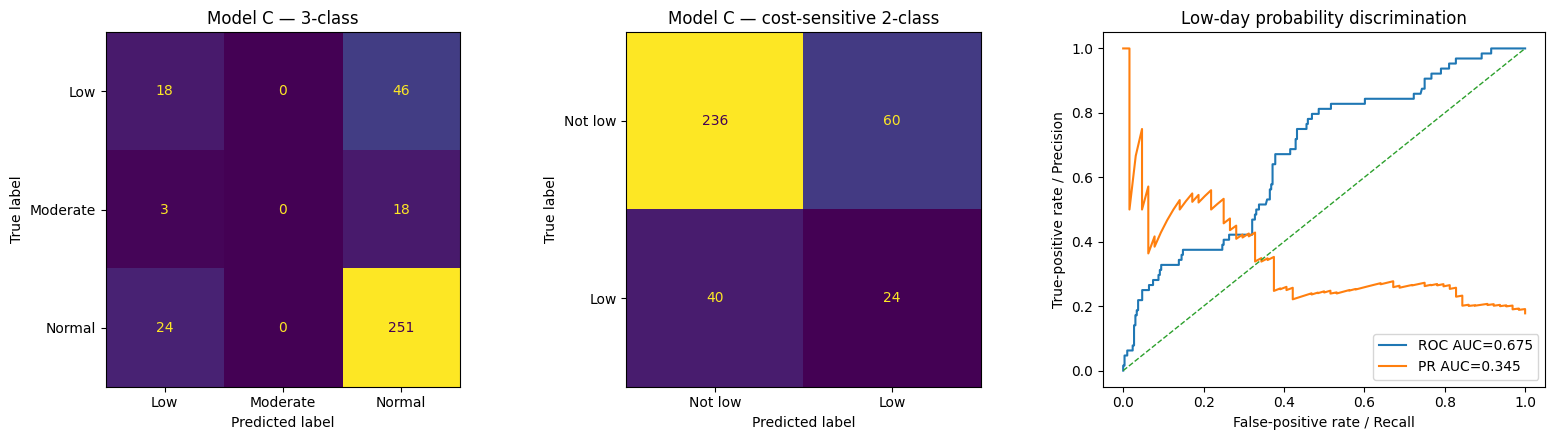

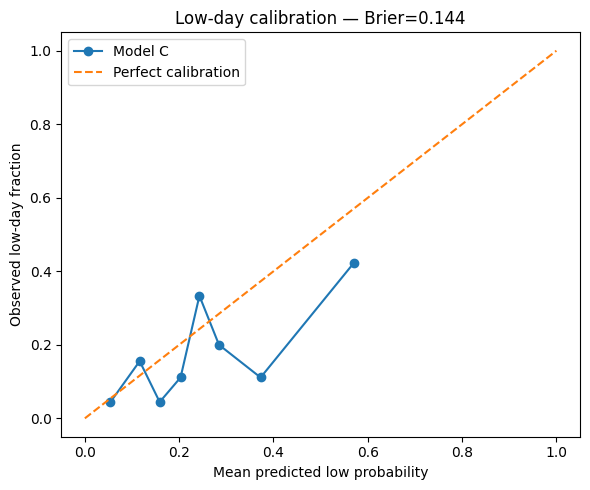

In [27]:
# Confusion matrices and probability diagnostics.
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix(y3_test, test_pred_3, labels=[0, 1, 2]),
    display_labels=["Low", "Moderate", "Normal"],
).plot(ax=axes[0], colorbar=False)
axes[0].set_title("Model C — 3-class")

pred_cost = (test_p_low >= COST_THRESHOLD).astype(int)
ConfusionMatrixDisplay(
    confusion_matrix(y2_test, pred_cost, labels=[0, 1]),
    display_labels=["Not low", "Low"],
).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Model C — cost-sensitive 2-class")

fpr, tpr, _ = roc_curve(y2_test, test_p_low)
precision, recall, _ = precision_recall_curve(y2_test, test_p_low)
axes[2].plot(fpr, tpr, label=f"ROC AUC={roc_auc_score(y2_test, test_p_low):.3f}")
axes[2].plot(recall, precision, label=f"PR AUC={average_precision_score(y2_test, test_p_low):.3f}")
axes[2].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
axes[2].set_xlabel("False-positive rate / Recall")
axes[2].set_ylabel("True-positive rate / Precision")
axes[2].set_title("Low-day probability discrimination")
axes[2].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_classification_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

frac_pos, mean_pred = calibration_curve(y2_test, test_p_low, n_bins=8, strategy="quantile")
plt.figure(figsize=(6, 5))
plt.plot(mean_pred, frac_pos, marker="o", label="Model C")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted low probability")
plt.ylabel("Observed low-day fraction")
plt.title(f"Low-day calibration — Brier={brier_score_loss(y2_test, test_p_low):.3f}")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_bayesian_low_calibration.png", dpi=160, bbox_inches="tight")
plt.show()

## 7. Regression accuracy and uncertainty coverage on the exact holdout

,model,split,n,mae,rmse,r2,coverage80,coverage95,mean_pi80_width,mean_pi95_width
0,Exact Bayesian Model C,paper-style random test,360,0.094972,0.130132,0.413458,0.844444,0.952778,0.391024,0.565803


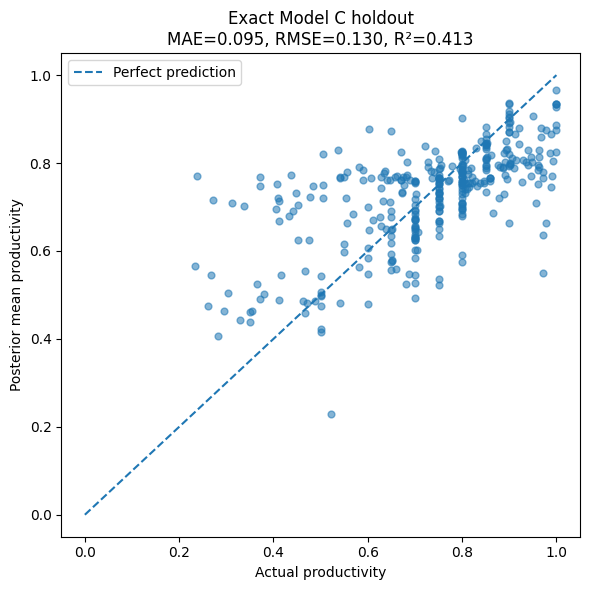

In [28]:
posterior_mean_test = mu_test_samples.mean(axis=0)
regression_summary = {
    "model": "Exact Bayesian Model C",
    "split": "paper-style random test",
    "n": len(y_test_saved),
    "mae": mean_absolute_error(y_test_saved, posterior_mean_test),
    "rmse": mean_squared_error(y_test_saved, posterior_mean_test) ** 0.5,
    "r2": r2_score(y_test_saved, posterior_mean_test),
}

if MODEL_C_TEST_TABLE_PATH.exists():
    interval_table = pd.read_csv(MODEL_C_TEST_TABLE_PATH)
    interval_table = interval_table.set_index("original_row_index").loc[test_indices].reset_index()
    regression_summary["coverage80"] = np.mean(
        (interval_table["actual_productivity"] >= interval_table["pi80_lower"])
        & (interval_table["actual_productivity"] <= interval_table["pi80_upper"])
    )
    regression_summary["coverage95"] = np.mean(
        (interval_table["actual_productivity"] >= interval_table["pi95_lower"])
        & (interval_table["actual_productivity"] <= interval_table["pi95_upper"])
    )
    regression_summary["mean_pi80_width"] = np.mean(interval_table["pi80_upper"] - interval_table["pi80_lower"])
    regression_summary["mean_pi95_width"] = np.mean(interval_table["pi95_upper"] - interval_table["pi95_lower"])
else:
    saved_metrics = metadata.get("test_metrics", {})
    regression_summary["coverage80"] = saved_metrics.get("coverage80", np.nan)
    regression_summary["coverage95"] = saved_metrics.get("coverage95", np.nan)
    regression_summary["mean_pi80_width"] = np.nan
    regression_summary["mean_pi95_width"] = np.nan

regression_metrics = pd.DataFrame([regression_summary])
regression_metrics.to_csv(OUTPUT_DIR / "validation_bayesian_regression_metrics.csv", index=False)
display(regression_metrics)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_saved, posterior_mean_test, alpha=0.55, s=24)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect prediction")
plt.xlabel("Actual productivity")
plt.ylabel("Posterior mean productivity")
plt.title(
    "Exact Model C holdout\n"
    f"MAE={regression_summary['mae']:.3f}, RMSE={regression_summary['rmse']:.3f}, "
    f"R²={regression_summary['r2']:.3f}"
)
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_bayesian_regression_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

## 8. PSIS-LOO and posterior driver validation against the garment paper

,Unnamed: 0,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
0,Model_C_final_monotone,0,562.184137,27.617370,0.000000,9.551571e-01,29.676019,0.000000,False,log
1,Model_B_hierarchical,1,468.186923,21.525167,93.997213,1.012652e-12,24.021913,14.575043,False,log
2,Model_A_baseline,2,441.976992,9.730148,120.207144,4.484290e-02,21.868118,16.984023,False,log


,variable,label,posterior_mean,hdi3,hdi97,prob_positive,prob_negative,direction,paper_comparison
0,b_inc_positive,Positive incentive vs zero,-0.570511,-0.866349,-0.286493,0.00025,0.99975,credibly negative,Paper: incentive is primary; expected alignmen...
1,b_wip,log WIP,0.408659,0.049043,0.761610,0.98175,0.01825,credibly positive,Paper: lower WIP is favorable; expected alignm...
2,b_ot,log overtime,-0.082871,-0.154156,-0.017421,0.01000,0.99000,credibly negative,Not a direct paper rule
3,b_smv,log SMV,0.020818,-0.212843,0.242442,0.57350,0.42650,uncertain / includes zero,Not a direct paper rule
4,b_nw,log workers,0.214928,-0.018045,0.457327,0.95900,0.04100,uncertain / includes zero,Paper: more workers can be favorable; expected...
5,b_tp,targeted productivity,0.175810,0.120833,0.232118,1.00000,0.00000,credibly positive,Not a direct paper rule
6,b_style,style changes,0.012998,-0.041024,0.068586,0.66525,0.33475,uncertain / includes zero,Not a direct paper rule
7,b_sin,weekday sine,0.003236,-0.048267,0.055537,0.54025,0.45975,uncertain / includes zero,Not a direct paper rule
8,b_cos,weekday cosine,0.000710,-0.048951,0.050659,0.52100,0.47900,uncertain / includes zero,Not a direct paper rule
9,b_dept,sewing department,-0.502103,-1.563577,0.546817,0.17875,0.82125,uncertain / includes zero,Not a direct paper rule


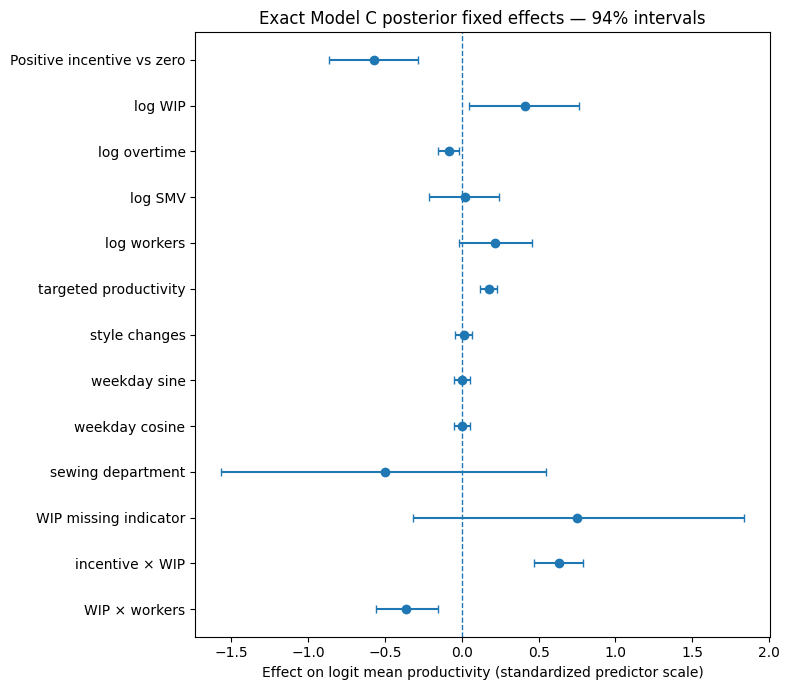

In [29]:
if LOO_PATH.exists():
    loo_table = pd.read_csv(LOO_PATH)
    loo_table.to_csv(OUTPUT_DIR / "validation_loo_comparison_copy.csv", index=False)
    display(loo_table)
else:
    loo_table = pd.DataFrame()
    print("LOO table not found; posterior driver validation will continue.")

fixed_effects = {
    "b_inc_positive": "Positive incentive vs zero",
    "b_wip": "log WIP",
    "b_ot": "log overtime",
    "b_smv": "log SMV",
    "b_nw": "log workers",
    "b_tp": "targeted productivity",
    "b_style": "style changes",
    "b_sin": "weekday sine",
    "b_cos": "weekday cosine",
    "b_dept": "sewing department",
    "b_wip_miss": "WIP missing indicator",
    "b_inc_wip": "incentive × WIP",
    "b_wip_nw": "WIP × workers",
}

driver_rows = []
for variable, label in fixed_effects.items():
    draws = posterior_samples(variable).reshape(-1)
    driver_rows.append({
        "variable": variable,
        "label": label,
        "posterior_mean": np.mean(draws),
        "hdi3": np.quantile(draws, 0.03),
        "hdi97": np.quantile(draws, 0.97),
        "prob_positive": np.mean(draws > 0),
        "prob_negative": np.mean(draws < 0),
    })

driver_table = pd.DataFrame(driver_rows)

def evidence_direction(row):
    if row["hdi3"] > 0:
        return "credibly positive"
    if row["hdi97"] < 0:
        return "credibly negative"
    return "uncertain / includes zero"

driver_table["direction"] = driver_table.apply(evidence_direction, axis=1)

paper_links = {
    "b_inc_positive": "Paper: incentive is primary; expected alignment is positive",
    "b_wip": "Paper: lower WIP is favorable; expected alignment is negative",
    "b_nw": "Paper: more workers can be favorable; expected alignment is positive",
    "b_inc_wip": "Paper rule combines incentive and WIP",
    "b_wip_nw": "Paper rule combines WIP and workers",
}
driver_table["paper_comparison"] = driver_table["variable"].map(paper_links).fillna("Not a direct paper rule")
driver_table.to_csv(OUTPUT_DIR / "validation_posterior_driver_table.csv", index=False)
display(driver_table)

plot_table = driver_table.iloc[::-1]
plt.figure(figsize=(8, 7))
plt.errorbar(
    plot_table["posterior_mean"],
    np.arange(len(plot_table)),
    xerr=[
        plot_table["posterior_mean"] - plot_table["hdi3"],
        plot_table["hdi97"] - plot_table["posterior_mean"],
    ],
    fmt="o",
    capsize=3,
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(np.arange(len(plot_table)), plot_table["label"])
plt.xlabel("Effect on logit mean productivity (standardized predictor scale)")
plt.title("Exact Model C posterior fixed effects — 94% intervals")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_posterior_drivers.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. Reconstruct the exact Model C prediction function for what-if validation

In [30]:
def b_spline_basis(x, knots, degree=3):
    x = np.asarray(x, dtype=float)
    knots = np.asarray(knots, dtype=float)
    knot_vector = np.concatenate([
        np.repeat(knots[0], degree),
        knots,
        np.repeat(knots[-1], degree),
    ])
    n_basis = len(knot_vector) - degree - 1
    basis = np.zeros((len(x), n_basis), dtype=float)
    for i in range(n_basis):
        coefficient = np.zeros(n_basis, dtype=float)
        coefficient[i] = 1.0
        spline = BSpline(knot_vector, coefficient, degree, extrapolate=False)
        basis[:, i] = spline(x)
    return np.nan_to_num(basis, nan=0.0, posinf=0.0, neginf=0.0)


def i_spline_basis(x, knots, degree=3):
    basis = b_spline_basis(x, knots, degree)
    cumulative = np.cumsum(basis[:, ::-1], axis=1)[:, ::-1]
    return cumulative[:, 1:]


FEATURES = list(metadata["feature_columns"])
SCALER_MEAN = np.asarray(metadata["scaler_mean"], float)
SCALER_SCALE = np.asarray(metadata["scaler_scale"], float)
COL = {name: i for i, name in enumerate(FEATURES)}
KNOTS = np.asarray(metadata["spline_knots_standardized_log_incentive"], float)
SPLINE_DEGREE = int(metadata["spline_degree"])
SPLINE_LOWER = float(metadata["spline_lower"])
SPLINE_UPPER = float(metadata["spline_upper"])
TEAM_LABELS = list(metadata["team_labels"])


def normalized_key(value):
    try:
        f = float(value)
        if f.is_integer():
            return str(int(f))
    except Exception:
        pass
    return str(value).strip()

TEAM_MAP = {normalized_key(value): idx for idx, value in enumerate(TEAM_LABELS)}

all_draws = posterior_samples("nu").shape[0]
if all_draws > MAX_POSTERIOR_DRAWS:
    MODEL_DRAW_IDX = np.sort(rng.choice(all_draws, MAX_POSTERIOR_DRAWS, replace=False))
else:
    MODEL_DRAW_IDX = np.arange(all_draws)


def pdraw(name):
    return posterior_samples(name)[MODEL_DRAW_IDX]

POST = {name: pdraw(name) for name in [
    "alpha_team", "mu_team", "w_spline", "b_inc_positive", "b_wip",
    "b_ot", "b_smv", "b_nw", "b_tp", "b_style", "b_sin", "b_cos",
    "b_dept", "b_wip_miss", "b_inc_wip", "b_wip_nw", "nu",
]}


def prepare_model_frame(frame):
    out = frame.copy()
    out["incentive"] = raw_from_columns(out, ["incentive"], ["log_incentive"]).fillna(0).clip(lower=0)
    out["wip_imputed"] = raw_from_columns(out, ["wip_imputed", "wip"], ["log_wip_imputed"]).fillna(0).clip(lower=0)
    out["over_time"] = raw_from_columns(out, ["over_time"], ["log_over_time"]).fillna(0).clip(lower=0)
    out["smv"] = raw_from_columns(out, ["smv"], ["log_smv"]).fillna(0).clip(lower=0)
    out["no_of_workers"] = raw_from_columns(out, ["no_of_workers"], ["log_workers"]).fillna(0).clip(lower=0)

    out["log_incentive"] = np.log1p(out["incentive"])
    out["log_wip_imputed"] = np.log1p(out["wip_imputed"])
    out["log_over_time"] = np.log1p(out["over_time"])
    out["log_smv"] = np.log1p(out["smv"])
    out["log_workers"] = np.log1p(out["no_of_workers"])

    if "sin_dow" not in out or "cos_dow" not in out:
        if "day_num" in out:
            day_num = pd.to_numeric(out["day_num"], errors="coerce").fillna(0)
        elif "date" in out:
            day_num = pd.to_datetime(out["date"], errors="coerce").dt.dayofweek.fillna(0)
        else:
            day_num = pd.Series(0, index=out.index)
        out["sin_dow"] = np.sin(2 * np.pi * day_num / 7)
        out["cos_dow"] = np.cos(2 * np.pi * day_num / 7)

    if "dept_bin" not in out:
        department = out.get("department", pd.Series("finishing", index=out.index)).astype(str).str.lower()
        out["dept_bin"] = department.str.contains("sew").astype(int)
    if "wip_missing_flag" not in out:
        out["wip_missing_flag"] = 0

    for col in FEATURES:
        if col not in out:
            raise KeyError(f"Model C feature missing from intervention frame: {col}")
        out[col] = pd.to_numeric(out[col], errors="coerce").fillna(0.0)
    return out


def model_c_mu_draws(frame, population_average_team=False):
    frame = prepare_model_frame(frame)
    X_raw = frame[FEATURES].to_numpy(float)
    X = (X_raw - SCALER_MEAN) / SCALER_SCALE

    incentive_std = X[:, COL["log_incentive"]]
    spline_x = np.clip(incentive_std, SPLINE_LOWER, SPLINE_UPPER)
    I = i_spline_basis(spline_x, KNOTS, degree=SPLINE_DEGREE)

    if population_average_team:
        intercept = POST["mu_team"][:, None]
    else:
        team_idx = np.array([
            TEAM_MAP.get(normalized_key(value), -1) for value in frame["team"]
        ])
        known = team_idx >= 0
        intercept = np.repeat(POST["mu_team"][:, None], len(frame), axis=1)
        if known.any():
            intercept[:, known] = POST["alpha_team"][:, team_idx[known]]

    inc_positive = (frame["incentive"].to_numpy(float) > 0).astype(float)
    wip = X[:, COL["log_wip_imputed"]]
    inc = X[:, COL["log_incentive"]]
    workers = X[:, COL["log_workers"]]

    eta = (
        intercept
        + POST["b_inc_positive"][:, None] * inc_positive[None, :]
        + POST["w_spline"] @ I.T
        + POST["b_wip"][:, None] * wip[None, :]
        + POST["b_ot"][:, None] * X[:, COL["log_over_time"]][None, :]
        + POST["b_smv"][:, None] * X[:, COL["log_smv"]][None, :]
        + POST["b_nw"][:, None] * workers[None, :]
        + POST["b_tp"][:, None] * X[:, COL["targeted_productivity"]][None, :]
        + POST["b_style"][:, None] * X[:, COL["no_of_style_change"]][None, :]
        + POST["b_sin"][:, None] * X[:, COL["sin_dow"]][None, :]
        + POST["b_cos"][:, None] * X[:, COL["cos_dow"]][None, :]
        + POST["b_dept"][:, None] * frame["dept_bin"].to_numpy(float)[None, :]
        + POST["b_wip_miss"][:, None] * frame["wip_missing_flag"].to_numpy(float)[None, :]
        + POST["b_inc_wip"][:, None] * (inc * wip)[None, :]
        + POST["b_wip_nw"][:, None] * (wip * workers)[None, :]
    )
    mu_beta = expit(np.clip(eta, -30, 30))
    if USES_SV:
        mu_original = (mu_beta * N_BETA - 0.5) / (N_BETA - 1)
    else:
        mu_original = mu_beta
    return np.clip(mu_original, 0.0, 1.0), POST["nu"].reshape(-1)


def low_risk_draws(mu_original, target_productivity, nu_draws):
    mu_beta = original_to_beta(mu_original)
    threshold_beta = original_to_beta(LOW_ACHIEVEMENT * np.asarray(target_productivity, float))
    alpha = np.clip(mu_beta * nu_draws[:, None], 1e-8, None)
    beta = np.clip((1 - mu_beta) * nu_draws[:, None], 1e-8, None)
    return betainc(alpha, beta, threshold_beta[None, :])

# Numerical identity check against the saved test predictions.
reconstructed_mu, reconstructed_nu = model_c_mu_draws(test_frame)
identity_check = pd.DataFrame([{
    "saved_mean_mae_vs_reconstructed": mean_absolute_error(
        mu_test_samples.mean(axis=0), reconstructed_mu.mean(axis=0)
    ),
    "saved_mean_max_abs_difference": np.max(np.abs(
        mu_test_samples.mean(axis=0) - reconstructed_mu.mean(axis=0)
    )),
    "posterior_draws_used_for_whatif": len(MODEL_DRAW_IDX),
}])
identity_check.to_csv(OUTPUT_DIR / "validation_model_c_reconstruction_check.csv", index=False)
display(identity_check)

,saved_mean_mae_vs_reconstructed,saved_mean_max_abs_difference,posterior_draws_used_for_whatif
0,0.000366,0.003452,1000


## 10. What-if uplift, risk reduction, and team heterogeneity

,intervention,mean_productivity_uplift,median_productivity_uplift,mean_low_risk_change,median_probability_positive,n
0,incentive_plus_20_BDT,-0.106208,0.042223,0.197612,0.9995,360
1,wip_minus_20_percent,-0.003258,0.000000,0.006103,0.0000,360
2,workers_plus_5,0.018815,-0.001080,-0.028003,0.3605,360


,team,n_test_rows,mean_uplift_plus20,p10,p90,prob_positive
4,5,24,-0.041474,-0.062855,-0.019559,0.014
10,11,27,-0.074354,-0.099199,-0.050125,0.000
1,2,24,-0.085851,-0.117210,-0.055017,0.000
7,8,35,-0.090416,-0.121211,-0.058475,0.000
2,3,30,-0.094697,-0.125331,-0.065429,0.000
5,6,22,-0.096097,-0.126775,-0.064348,0.000
8,9,44,-0.100672,-0.131123,-0.070562,0.000
6,7,32,-0.107753,-0.141823,-0.071922,0.000
11,12,29,-0.115192,-0.148261,-0.082058,0.000
9,10,31,-0.146166,-0.184478,-0.107256,0.000


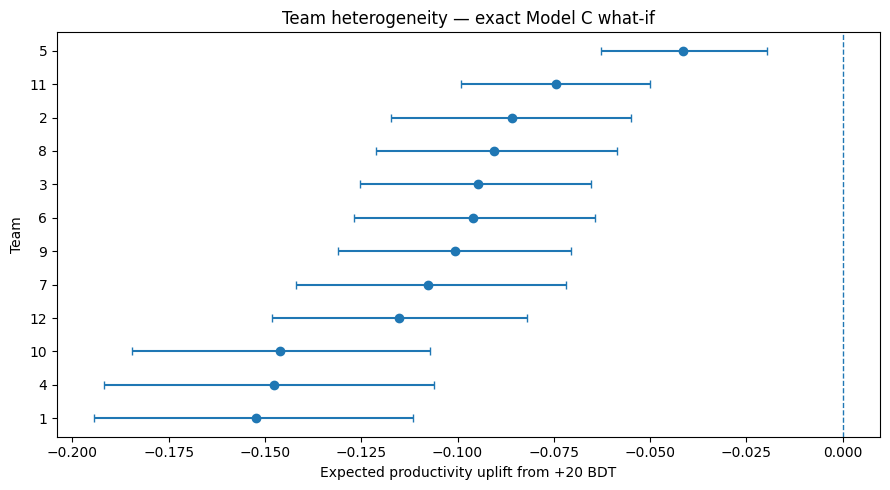

In [31]:
base = test_frame.copy()
inc_plus_20 = base.copy()
inc_plus_20["incentive"] = inc_plus_20["incentive"] + 20.0

wip_minus_20pct = base.copy()
wip_minus_20pct["wip_imputed"] = 0.8 * wip_minus_20pct["wip_imputed"]

workers_plus_5 = base.copy()
workers_plus_5["no_of_workers"] = workers_plus_5["no_of_workers"] + 5.0

mu_base, nu_sub = model_c_mu_draws(base)
risk_base = low_risk_draws(mu_base, base["targeted_productivity"].to_numpy(float), nu_sub)

interventions = {
    "incentive_plus_20_BDT": inc_plus_20,
    "wip_minus_20_percent": wip_minus_20pct,
    "workers_plus_5": workers_plus_5,
}

whatif_rows = []
intervention_draws = {}
for name, scenario in interventions.items():
    mu_s, _ = model_c_mu_draws(scenario)
    risk_s = low_risk_draws(mu_s, scenario["targeted_productivity"].to_numpy(float), nu_sub)
    uplift = mu_s - mu_base
    risk_change = risk_s - risk_base
    intervention_draws[name] = {"uplift": uplift, "risk_change": risk_change}

    for j, original_idx in enumerate(base["original_row_index"].to_numpy(int)):
        whatif_rows.append({
            "original_row_index": original_idx,
            "team": base.iloc[j]["team"],
            "intervention": name,
            "mean_productivity_uplift": uplift[:, j].mean(),
            "uplift_p10": np.quantile(uplift[:, j], 0.10),
            "uplift_p90": np.quantile(uplift[:, j], 0.90),
            "mean_low_risk_change": risk_change[:, j].mean(),
            "probability_positive_uplift": np.mean(uplift[:, j] > 0),
        })

whatif_table = pd.DataFrame(whatif_rows)
whatif_table.to_csv(OUTPUT_DIR / "validation_whatif_row_level.csv", index=False)

whatif_summary = whatif_table.groupby("intervention").agg(
    mean_productivity_uplift=("mean_productivity_uplift", "mean"),
    median_productivity_uplift=("mean_productivity_uplift", "median"),
    mean_low_risk_change=("mean_low_risk_change", "mean"),
    median_probability_positive=("probability_positive_uplift", "median"),
    n=("original_row_index", "size"),
).reset_index()
whatif_summary.to_csv(OUTPUT_DIR / "validation_whatif_summary.csv", index=False)
display(whatif_summary)

# Team heterogeneity for the incentive intervention.
uplift_inc = intervention_draws["incentive_plus_20_BDT"]["uplift"]
team_rows = []
for team, idx in base.groupby("team").groups.items():
    idx = np.asarray(list(idx), int)
    team_draw = uplift_inc[:, idx].mean(axis=1)
    team_rows.append({
        "team": team,
        "n_test_rows": len(idx),
        "mean_uplift_plus20": team_draw.mean(),
        "p10": np.quantile(team_draw, 0.10),
        "p90": np.quantile(team_draw, 0.90),
        "prob_positive": np.mean(team_draw > 0),
    })
team_heterogeneity = pd.DataFrame(team_rows).sort_values("mean_uplift_plus20", ascending=False)
team_heterogeneity.to_csv(OUTPUT_DIR / "validation_team_heterogeneity.csv", index=False)
display(team_heterogeneity)

plt.figure(figsize=(9, 5))
plot_team = team_heterogeneity.sort_values("mean_uplift_plus20")
plt.errorbar(
    plot_team["mean_uplift_plus20"],
    np.arange(len(plot_team)),
    xerr=[plot_team["mean_uplift_plus20"] - plot_team["p10"],
          plot_team["p90"] - plot_team["mean_uplift_plus20"]],
    fmt="o", capsize=3,
)
plt.axvline(0, linestyle="--", linewidth=1)
plt.yticks(np.arange(len(plot_team)), plot_team["team"].astype(str))
plt.xlabel("Expected productivity uplift from +20 BDT")
plt.ylabel("Team")
plt.title("Team heterogeneity — exact Model C what-if")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_team_heterogeneity.png", dpi=160, bbox_inches="tight")
plt.show()

## 11. Actionable incentive threshold and diminishing returns

,wip_scenario,wip_pieces,minimum_incentive_for_risk_le_20pct,risk_near_69_5_bdt,expected_productivity_near_69_5_bdt,diminishing_returns_candidate_bdt,paper_threshold_bdt
0,Low WIP,0.0,NaN,0.824233,0.396576,10.0,69.5
1,Median WIP,560.0,55.0,0.112722,0.820369,115.0,69.5
2,High WIP,1075.0,45.0,0.081607,0.846770,100.0,69.5


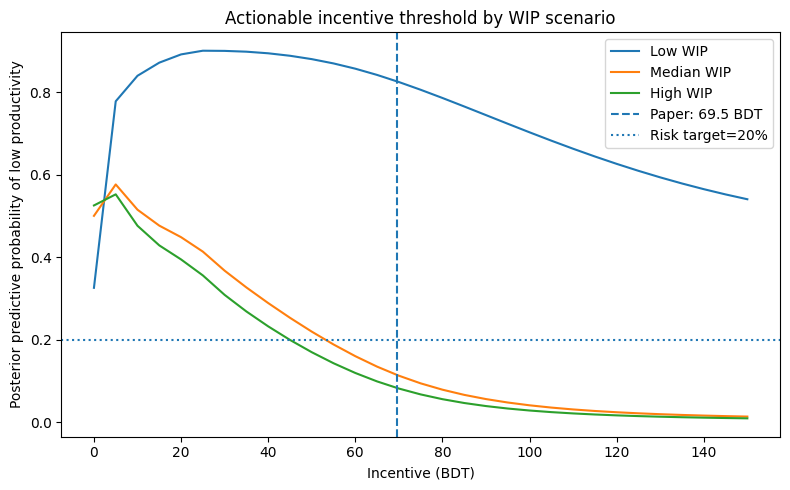

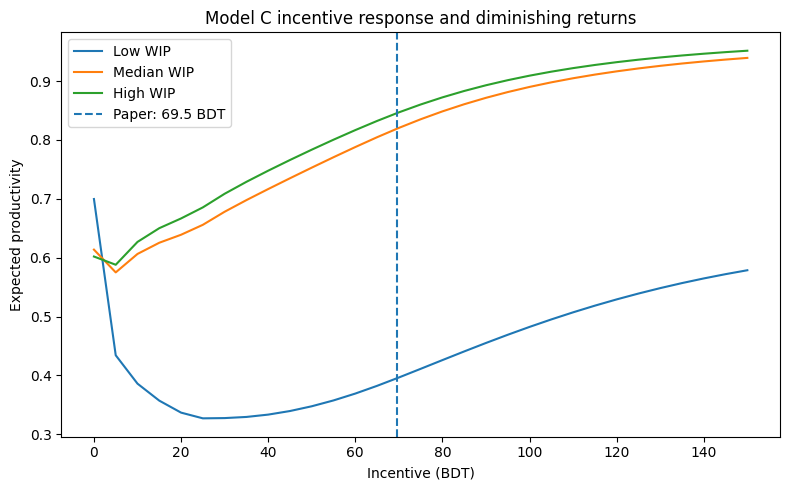

In [32]:
# Average policy curves over a representative panel of held-out rows.
panel = base.sample(n=min(120, len(base)), random_state=RANDOM_SEED).reset_index(drop=True)
fit_frame = df.iloc[fit_indices].copy()
wip_levels = np.quantile(fit_frame["wip_imputed"], [0.25, 0.50, 0.75])
wip_names = ["Low WIP", "Median WIP", "High WIP"]
incentive_grid = np.arange(0.0, 155.0, 5.0)

curve_rows = []
for wip_name, wip_level in zip(wip_names, wip_levels):
    for incentive_value in incentive_grid:
        scenario = panel.copy()
        scenario["incentive"] = incentive_value
        scenario["wip_imputed"] = wip_level
        scenario["wip_missing_flag"] = 0
        mu_s, nu_s = model_c_mu_draws(scenario, population_average_team=False)
        risk_s = low_risk_draws(mu_s, scenario["targeted_productivity"].to_numpy(float), nu_s)
        mean_prod_draw = mu_s.mean(axis=1)
        mean_risk_draw = risk_s.mean(axis=1)
        curve_rows.append({
            "wip_scenario": wip_name,
            "wip_pieces": wip_level,
            "incentive_bdt": incentive_value,
            "expected_productivity": mean_prod_draw.mean(),
            "productivity_p10": np.quantile(mean_prod_draw, 0.10),
            "productivity_p90": np.quantile(mean_prod_draw, 0.90),
            "low_risk": mean_risk_draw.mean(),
            "risk_p10": np.quantile(mean_risk_draw, 0.10),
            "risk_p90": np.quantile(mean_risk_draw, 0.90),
        })

threshold_curves = pd.DataFrame(curve_rows)
threshold_curves.to_csv(OUTPUT_DIR / "validation_incentive_threshold_curves.csv", index=False)

threshold_rows = []
for scenario, sub in threshold_curves.groupby("wip_scenario", sort=False):
    feasible = sub[sub["low_risk"] <= RISK_TARGET]
    threshold_value = feasible["incentive_bdt"].min() if len(feasible) else np.nan
    paper_row = sub.iloc[(sub["incentive_bdt"] - PAPER_INCENTIVE_THRESHOLD).abs().argmin()]
    marginal = np.gradient(sub["expected_productivity"].to_numpy(float), sub["incentive_bdt"].to_numpy(float))
    max_marginal = np.nanmax(marginal)
    diminishing_candidates = sub.loc[(sub["incentive_bdt"] >= 10) & (marginal <= 0.25 * max_marginal), "incentive_bdt"]
    diminishing = diminishing_candidates.min() if len(diminishing_candidates) else np.nan
    threshold_rows.append({
        "wip_scenario": scenario,
        "wip_pieces": sub["wip_pieces"].iloc[0],
        "minimum_incentive_for_risk_le_20pct": threshold_value,
        "risk_near_69_5_bdt": paper_row["low_risk"],
        "expected_productivity_near_69_5_bdt": paper_row["expected_productivity"],
        "diminishing_returns_candidate_bdt": diminishing,
        "paper_threshold_bdt": PAPER_INCENTIVE_THRESHOLD,
    })
threshold_summary = pd.DataFrame(threshold_rows)
threshold_summary.to_csv(OUTPUT_DIR / "validation_actionable_thresholds.csv", index=False)
display(threshold_summary)

plt.figure(figsize=(8, 5))
for scenario, sub in threshold_curves.groupby("wip_scenario", sort=False):
    plt.plot(sub["incentive_bdt"], sub["low_risk"], label=scenario)
plt.axvline(PAPER_INCENTIVE_THRESHOLD, linestyle="--", label="Paper: 69.5 BDT")
plt.axhline(RISK_TARGET, linestyle=":", label=f"Risk target={RISK_TARGET:.0%}")
plt.xlabel("Incentive (BDT)")
plt.ylabel("Posterior predictive probability of low productivity")
plt.title("Actionable incentive threshold by WIP scenario")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_incentive_threshold.png", dpi=160, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
for scenario, sub in threshold_curves.groupby("wip_scenario", sort=False):
    plt.plot(sub["incentive_bdt"], sub["expected_productivity"], label=scenario)
plt.axvline(PAPER_INCENTIVE_THRESHOLD, linestyle="--", label="Paper: 69.5 BDT")
plt.xlabel("Incentive (BDT)")
plt.ylabel("Expected productivity")
plt.title("Model C incentive response and diminishing returns")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_incentive_productivity_curve.png", dpi=160, bbox_inches="tight")
plt.show()

## 12. Missing-WIP sensitivity analysis

In [33]:
missing_test = base[pd.to_numeric(base["wip_missing_flag"], errors="coerce").fillna(0).eq(1)].copy()
if len(missing_test):
    current = missing_test.copy()
    zero_wip = missing_test.copy()
    zero_wip["wip_imputed"] = 0.0

    dept_median = fit_frame.groupby("dept_bin")["wip_imputed"].median()
    median_wip = missing_test.copy()
    median_wip["wip_imputed"] = median_wip["dept_bin"].map(dept_median).fillna(fit_frame["wip_imputed"].median())

    sensitivity_rows = []
    scenario_predictions = {}
    for name, frame in {
        "Model C cleaned/imputed value": current,
        "Sensitivity: WIP = 0": zero_wip,
        "Sensitivity: department median WIP": median_wip,
    }.items():
        mu_s, nu_s = model_c_mu_draws(frame)
        risk_s = low_risk_draws(mu_s, frame["targeted_productivity"].to_numpy(float), nu_s)
        scenario_predictions[name] = mu_s
        sensitivity_rows.append({
            "scenario": name,
            "n_missing_wip_test_rows": len(frame),
            "mean_expected_productivity": mu_s.mean(),
            "mean_low_risk": risk_s.mean(),
        })

    wip_sensitivity = pd.DataFrame(sensitivity_rows)
    wip_sensitivity.to_csv(OUTPUT_DIR / "validation_missing_wip_sensitivity.csv", index=False)
    display(wip_sensitivity)
else:
    wip_sensitivity = pd.DataFrame()
    print("No missing-WIP rows occur in the exact Model C test split.")

,scenario,n_missing_wip_test_rows,mean_expected_productivity,mean_low_risk
0,Model C cleaned/imputed value,146,0.774728,0.178086
1,Sensitivity: WIP = 0,146,0.774728,0.178086
2,Sensitivity: department median WIP,146,0.774728,0.178086


## 13. Offline budget allocation using posterior expected uplift

,budget_bdt,number_of_allocations,greedy_expected_total_uplift,greedy_total_uplift_p10,greedy_total_uplift_p90,random_expected_total_uplift_mean,random_expected_total_uplift_p95,probability_greedy_beats_random_draw
0,720.0,72,3.476714,2.967023,3.975758,-7.659015,-5.524787,1.0


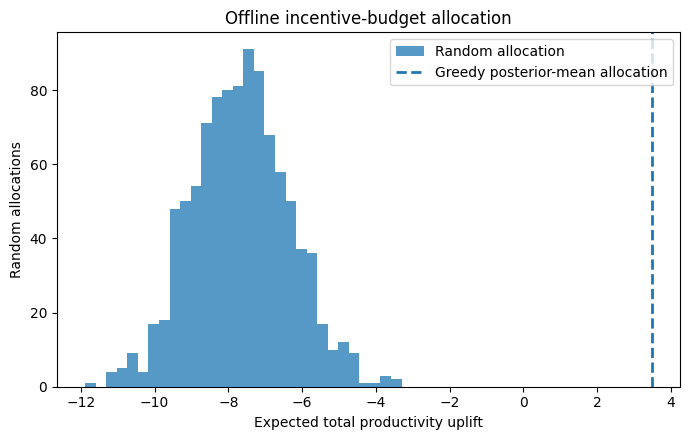

In [34]:
# This is a model-based offline policy simulation, not a causal estimate.
budget_increment = 10.0
budget_scenario = base.copy()
budget_scenario["incentive"] = budget_scenario["incentive"] + budget_increment
mu_budget, _ = model_c_mu_draws(budget_scenario)
uplift_budget = mu_budget - mu_base
mean_uplift_budget = uplift_budget.mean(axis=0)

n_slots = max(1, int(np.ceil(0.20 * len(base))))
greedy_idx = np.argsort(mean_uplift_budget)[-n_slots:]
greedy_total_draw = uplift_budget[:, greedy_idx].sum(axis=1)

random_totals = []
for _ in range(BOOTSTRAP_REPS):
    idx = rng.choice(len(base), n_slots, replace=False)
    random_totals.append(uplift_budget[:, idx].mean(axis=0).sum())
random_totals = np.asarray(random_totals)

allocation = pd.DataFrame({
    "original_row_index": base["original_row_index"].to_numpy(int),
    "team": base["team"].to_numpy(),
    "current_incentive": base["incentive"].to_numpy(float),
    "increment_bdt": budget_increment,
    "mean_expected_uplift": mean_uplift_budget,
    "selected_by_greedy": False,
})
allocation.loc[greedy_idx, "selected_by_greedy"] = True
allocation = allocation.sort_values("mean_expected_uplift", ascending=False)
allocation.to_csv(OUTPUT_DIR / "validation_budget_allocation.csv", index=False)

allocation_summary = pd.DataFrame([{
    "budget_bdt": budget_increment * n_slots,
    "number_of_allocations": n_slots,
    "greedy_expected_total_uplift": greedy_total_draw.mean(),
    "greedy_total_uplift_p10": np.quantile(greedy_total_draw, 0.10),
    "greedy_total_uplift_p90": np.quantile(greedy_total_draw, 0.90),
    "random_expected_total_uplift_mean": random_totals.mean(),
    "random_expected_total_uplift_p95": np.quantile(random_totals, 0.95),
    "probability_greedy_beats_random_draw": np.mean(greedy_total_draw.mean() > random_totals),
}])
allocation_summary.to_csv(OUTPUT_DIR / "validation_budget_allocation_summary.csv", index=False)
display(allocation_summary)

plt.figure(figsize=(7, 4.5))
plt.hist(random_totals, bins=30, alpha=0.75, label="Random allocation")
plt.axvline(greedy_total_draw.mean(), linestyle="--", linewidth=2, label="Greedy posterior-mean allocation")
plt.xlabel("Expected total productivity uplift")
plt.ylabel("Random allocations")
plt.title("Offline incentive-budget allocation")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "validation_budget_utility.png", dpi=160, bbox_inches="tight")
plt.show()

## 14. Kalman temporal validation, calendar effects, and style-change drift

Using Kalman forecast file:
/content/ProdFusion/models/03_v7_1_forecasts.csv
✓ Kalman rows aligned: 1197


,model,split,n,mae,rmse,r2,coverage80,coverage95,paper_low_auc,paper_low_ap,paper_low_brier,paper_3class_accuracy
0,Kalman DLM v7.1 final forecast,future temporal test,192,0.085974,0.131608,0.278457,0.885417,0.979167,0.715432,0.347646,0.127182,0.765625


,style_change_flag,n,mean_actual,mean_forecast,mean_abs_standardized_innovation,change_point_rate,mannwhitney_pvalue
0,0,272,0.717388,0.743499,0.696777,0.073529,0.559422
1,1,102,0.649019,0.627252,0.690797,0.068627,0.559422


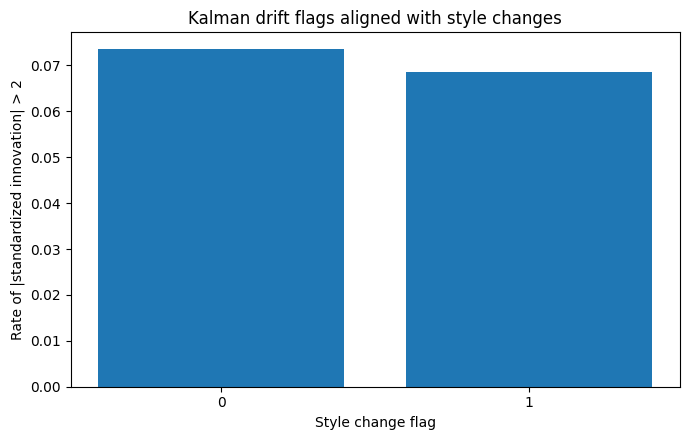

In [35]:
# ── Validate the exact corrected Kalman DLM v7.1 output ───────────────────────

kalman_metrics = pd.DataFrame()
kalman_merged = pd.DataFrame()
kalman_test = pd.DataFrame()

# Exact forecast file created by:
# 03_kalman_dlm_v7_1_corrected_colab (1).ipynb
KALMAN_FORECAST_PATH = MODEL_DIR / "03_v7_1_forecasts.csv"

if not KALMAN_FORECAST_PATH.exists():
    raise FileNotFoundError(
        "The corrected Kalman forecast file was not found:\n"
        f"{KALMAN_FORECAST_PATH}\n\n"
        "Run the Kalman notebook through Section 12.1 and push "
        "models/03_v7_1_forecasts.csv to GitHub."
    )

print("Using Kalman forecast file:")
print(KALMAN_FORECAST_PATH)

# ── 1. Load the exact Kalman v7.1 forecasts ───────────────────────────────────

kf = pd.read_csv(KALMAN_FORECAST_PATH)
kf.columns = kf.columns.str.strip()

required_k = [
    "team_dept_idx",
    "team",
    "dept_bin",
    "date",
    "t",
    "split_code",
    "actual_y",
    "y_pred",
    "pred_sd_raw",
    "innovation",
    "innovation_std",
    "y_lo80",
    "y_hi80",
    "y_lo95",
    "y_hi95",
]

missing_k = [column for column in required_k if column not in kf.columns]

if missing_k:
    raise KeyError(
        "03_v7_1_forecasts.csv is missing these required columns:\n"
        + "\n".join(f"  - {column}" for column in missing_k)
    )

kf["date"] = pd.to_datetime(kf["date"], errors="raise")

for column in [
    "team_dept_idx",
    "team",
    "dept_bin",
    "t",
    "split_code",
]:
    kf[column] = pd.to_numeric(
        kf[column],
        errors="raise",
    ).astype(int)

for column in [
    "actual_y",
    "y_pred",
    "pred_sd_raw",
    "innovation",
    "innovation_std",
    "y_lo80",
    "y_hi80",
    "y_lo95",
    "y_hi95",
]:
    kf[column] = pd.to_numeric(
        kf[column],
        errors="coerce",
    )

# ── 2. Prepare the Bayesian/cleaned data only for row alignment ───────────────

data_for_merge = df.copy()

if "original_row_index" not in data_for_merge.columns:
    data_for_merge["original_row_index"] = np.arange(
        len(data_for_merge),
        dtype=int,
    )

if "date" in data_for_merge.columns:
    data_for_merge["date"] = pd.to_datetime(
        data_for_merge["date"],
        errors="coerce",
    )

for column in [
    "team_dept_idx",
    "team",
    "dept_bin",
    "t",
]:
    if column in data_for_merge.columns:
        data_for_merge[column] = pd.to_numeric(
            data_for_merge[column],
            errors="coerce",
        ).astype("Int64")

# Reconstruct raw variables when only log variables are available.
if "incentive" not in data_for_merge.columns:
    data_for_merge["incentive"] = np.expm1(
        pd.to_numeric(
            data_for_merge["log_incentive"],
            errors="coerce",
        )
    )

if "wip_imputed" not in data_for_merge.columns:
    data_for_merge["wip_imputed"] = np.expm1(
        pd.to_numeric(
            data_for_merge["log_wip_imputed"],
            errors="coerce",
        )
    )

if "no_of_workers" not in data_for_merge.columns:
    data_for_merge["no_of_workers"] = np.expm1(
        pd.to_numeric(
            data_for_merge["log_workers"],
            errors="coerce",
        )
    )

# Create paper-compatible classes if not already available.
if "class3_paper" not in data_for_merge.columns:
    actual_raw = pd.to_numeric(
        data_for_merge["actual_productivity"],
        errors="coerce",
    )

    target_raw = pd.to_numeric(
        data_for_merge["targeted_productivity"],
        errors="coerce",
    ).replace(0, np.nan)

    achievement = (
        actual_raw / target_raw
    ).replace(
        [np.inf, -np.inf],
        np.nan,
    ).fillna(0.0)

    data_for_merge["class3_paper"] = np.select(
        [
            achievement < LOW_ACHIEVEMENT,
            achievement < NORMAL_ACHIEVEMENT,
        ],
        [0, 1],
        default=2,
    ).astype(int)

if "low_paper" not in data_for_merge.columns:
    data_for_merge["low_paper"] = (
        data_for_merge["class3_paper"] == 0
    ).astype(int)

# team_dept_idx + t is the exact unique key used by the Kalman notebook.
merge_cols = ["team_dept_idx", "t"]

if not set(merge_cols).issubset(data_for_merge.columns):
    merge_cols = ["date", "team", "dept_bin", "t"]

if data_for_merge.duplicated(merge_cols).any():
    duplicates = data_for_merge.loc[
        data_for_merge.duplicated(
            merge_cols,
            keep=False,
        ),
        merge_cols,
    ].head(10)

    raise RuntimeError(
        "The cleaned dataset is not unique using the Kalman keys:\n"
        f"{duplicates}"
    )

carry_candidates = [
    "original_row_index",
    "actual_productivity",
    "targeted_productivity",
    "class3_paper",
    "low_paper",
    "no_of_style_change",
    "incentive",
    "wip_imputed",
    "no_of_workers",
    "quarter",
    "day_num",
    "sin_dow",
    "cos_dow",
]

carry_cols = merge_cols.copy()

for column in carry_candidates:
    if (
        column in data_for_merge.columns
        and column not in carry_cols
    ):
        carry_cols.append(column)

kalman_merged = kf.merge(
    data_for_merge[carry_cols],
    on=merge_cols,
    how="left",
    validate="many_to_one",
)

if kalman_merged["original_row_index"].isna().any():
    unmatched = kalman_merged.loc[
        kalman_merged["original_row_index"].isna(),
        ["team_dept_idx", "team", "dept_bin", "date", "t"],
    ].head(10)

    raise RuntimeError(
        "Some Kalman rows could not be matched to the cleaned dataset:\n"
        f"{unmatched}"
    )

kalman_merged["original_row_index"] = (
    kalman_merged["original_row_index"].astype(int)
)

# Verify that the Kalman target matches the original, un-clipped target.
if "actual_productivity" in kalman_merged.columns:
    target_difference = np.abs(
        pd.to_numeric(
            kalman_merged["actual_productivity"],
            errors="coerce",
        )
        - kalman_merged["actual_y"]
    )

    if target_difference.max() > 1e-6:
        raise RuntimeError(
            "Kalman actual_y does not match actual_productivity. "
            f"Maximum difference: {target_difference.max():.8f}"
        )

print(
    "✓ Kalman rows aligned:",
    len(kalman_merged),
)

# ── 3. Convert Kalman forecasts into paper-compatible probabilities ───────────

sd = pd.to_numeric(
    kalman_merged["pred_sd_raw"],
    errors="coerce",
)

if sd.isna().all():
    residual_sd = np.std(
        kalman_merged["actual_y"]
        - kalman_merged["y_pred"]
    )

    sd = pd.Series(
        residual_sd,
        index=kalman_merged.index,
    )

sd = (
    sd
    .fillna(sd.median())
    .clip(lower=1e-6)
)

kalman_merged["paper_p_low"] = stats.norm.cdf(
    (
        LOW_ACHIEVEMENT
        * kalman_merged["targeted_productivity"]
        - kalman_merged["y_pred"]
    )
    / sd
)

cdf_below_normal = stats.norm.cdf(
    (
        NORMAL_ACHIEVEMENT
        * kalman_merged["targeted_productivity"]
        - kalman_merged["y_pred"]
    )
    / sd
)

kalman_merged["paper_p_moderate"] = np.clip(
    cdf_below_normal
    - kalman_merged["paper_p_low"],
    0.0,
    1.0,
)

kalman_merged["paper_p_normal"] = np.clip(
    1.0 - cdf_below_normal,
    0.0,
    1.0,
)

probability_columns = [
    "paper_p_low",
    "paper_p_moderate",
    "paper_p_normal",
]

probability_total = (
    kalman_merged[probability_columns]
    .sum(axis=1)
    .replace(0, 1)
)

kalman_merged[probability_columns] = (
    kalman_merged[probability_columns]
    .div(probability_total, axis=0)
)

# ── 4. Temporal test metrics ──────────────────────────────────────────────────

kalman_test = kalman_merged.loc[
    kalman_merged["split_code"].eq(2)
].copy()

if kalman_test.empty:
    raise RuntimeError(
        "No Kalman temporal test rows were found with split_code == 2."
    )

y = kalman_test["actual_y"].to_numpy(dtype=float)
y_pred = kalman_test["y_pred"].to_numpy(dtype=float)

probs_k = kalman_test[
    probability_columns
].to_numpy(dtype=float)

predicted_class3 = np.argmax(
    probs_k,
    axis=1,
)

low_true = kalman_test["low_paper"].astype(int)

if low_true.nunique() == 2:
    low_auc = safe_auc_binary(
        low_true,
        kalman_test["paper_p_low"],
    )

    low_ap = average_precision_score(
        low_true,
        kalman_test["paper_p_low"],
    )

    low_brier = brier_score_loss(
        low_true,
        kalman_test["paper_p_low"],
    )
else:
    low_auc = np.nan
    low_ap = np.nan
    low_brier = np.nan

kalman_metrics = pd.DataFrame([{
    "model": "Kalman DLM v7.1 final forecast",
    "split": "future temporal test",
    "n": len(kalman_test),
    "mae": mean_absolute_error(y, y_pred),
    "rmse": mean_squared_error(y, y_pred) ** 0.5,
    "r2": r2_score(y, y_pred),
    "coverage80": np.mean(
        (y >= kalman_test["y_lo80"])
        & (y <= kalman_test["y_hi80"])
    ),
    "coverage95": np.mean(
        (y >= kalman_test["y_lo95"])
        & (y <= kalman_test["y_hi95"])
    ),
    "paper_low_auc": low_auc,
    "paper_low_ap": low_ap,
    "paper_low_brier": low_brier,
    "paper_3class_accuracy": accuracy_score(
        kalman_test["class3_paper"],
        predicted_class3,
    ),
}])

kalman_metrics.to_csv(
    OUTPUT_DIR / "validation_kalman_temporal_metrics.csv",
    index=False,
)

kalman_merged.to_csv(
    OUTPUT_DIR / "validation_kalman_aligned_forecasts.csv",
    index=False,
)

display(kalman_metrics)

# ── 5. Calendar and style-change drift diagnostics ────────────────────────────

analysis_k = kalman_merged.loc[
    kalman_merged["split_code"].isin([1, 2])
].copy()

analysis_k["forecast_error"] = (
    analysis_k["actual_y"]
    - analysis_k["y_pred"]
)

analysis_k["abs_innovation_std"] = (
    pd.to_numeric(
        analysis_k["innovation_std"],
        errors="coerce",
    )
    .abs()
)

analysis_k["change_point_flag"] = (
    analysis_k["abs_innovation_std"] > 2.0
).astype(int)

analysis_k["style_change_flag"] = (
    pd.to_numeric(
        analysis_k["no_of_style_change"],
        errors="coerce",
    )
    .fillna(0)
    > 0
).astype(int)

analysis_k["weekday"] = (
    pd.to_datetime(
        analysis_k["date"],
        errors="coerce",
    )
    .dt.day_name()
)

analysis_k["month_day"] = (
    pd.to_datetime(
        analysis_k["date"],
        errors="coerce",
    )
    .dt.day
)

analysis_k["quarter_of_month"] = pd.cut(
    analysis_k["month_day"],
    bins=[0, 7, 14, 21, 31],
    labels=["Q1", "Q2", "Q3", "Q4"],
)

calendar_table = (
    analysis_k
    .groupby(
        ["weekday", "quarter_of_month"],
        observed=True,
    )
    .agg(
        n=("actual_y", "size"),
        mean_error=("forecast_error", "mean"),
        mean_abs_standardized_innovation=(
            "abs_innovation_std",
            "mean",
        ),
        change_point_rate=(
            "change_point_flag",
            "mean",
        ),
    )
    .reset_index()
)

calendar_table.to_csv(
    OUTPUT_DIR / "validation_calendar_effects.csv",
    index=False,
)

style_table = (
    analysis_k
    .groupby("style_change_flag")
    .agg(
        n=("actual_y", "size"),
        mean_actual=("actual_y", "mean"),
        mean_forecast=("y_pred", "mean"),
        mean_abs_standardized_innovation=(
            "abs_innovation_std",
            "mean",
        ),
        change_point_rate=(
            "change_point_flag",
            "mean",
        ),
    )
    .reset_index()
)

if analysis_k["style_change_flag"].nunique() == 2:
    style_change_innovations = analysis_k.loc[
        analysis_k["style_change_flag"].eq(1),
        "abs_innovation_std",
    ].dropna()

    no_style_change_innovations = analysis_k.loc[
        analysis_k["style_change_flag"].eq(0),
        "abs_innovation_std",
    ].dropna()

    if (
        len(style_change_innovations) > 0
        and len(no_style_change_innovations) > 0
    ):
        test_result = stats.mannwhitneyu(
            style_change_innovations,
            no_style_change_innovations,
            alternative="two-sided",
        )

        style_table["mannwhitney_pvalue"] = (
            test_result.pvalue
        )

style_table.to_csv(
    OUTPUT_DIR / "validation_style_change_drift.csv",
    index=False,
)

display(style_table)

plt.figure(figsize=(7, 4.5))

plt.bar(
    style_table["style_change_flag"].astype(str),
    style_table["change_point_rate"],
)

plt.xlabel("Style change flag")
plt.ylabel("Rate of |standardized innovation| > 2")
plt.title("Kalman drift flags aligned with style changes")
plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "validation_style_change_drift.png",
    dpi=160,
    bbox_inches="tight",
)

plt.show()

## 15. Bayesian + Kalman combined validation on the dual-holdout intersection

,model,task,decision_threshold,accuracy,balanced_accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,low_precision,low_recall,low_f1,auc,average_precision,brier,log_loss,n
0,Bayesian Model C — dual holdout,3-class,NaN,0.767857,0.339286,0.333333,0.339286,0.336279,0.760125,0.142857,0.142857,0.142857,0.449176,NaN,NaN,0.679042,56
1,Kalman — dual holdout,3-class,NaN,0.821429,0.441468,0.441468,0.441468,0.441468,0.821429,0.428571,0.428571,0.428571,0.720444,NaN,NaN,0.577120,56
2,Bayesian + Kalman equal-weight ensemble,3-class,NaN,0.821429,0.360119,0.371795,0.360119,0.360606,0.794156,0.250000,0.142857,0.181818,0.631750,NaN,NaN,0.612779,56
3,Bayesian Model C — dual holdout,2-class,0.333333,0.625000,0.418367,0.456250,0.418367,0.425501,0.679409,0.062500,0.142857,0.086957,0.472303,0.146124,0.151174,0.474677,56
4,Kalman — dual holdout,2-class,0.333333,0.821429,0.653061,0.624113,0.653061,0.635417,0.830729,0.333333,0.428571,0.375000,0.752187,0.455825,0.101052,0.337752,56
5,Bayesian + Kalman equal-weight ensemble,2-class,0.333333,0.767857,0.683673,0.607143,0.683673,0.619048,0.797619,0.285714,0.571429,0.380952,0.667638,0.244987,0.119280,0.392934,56


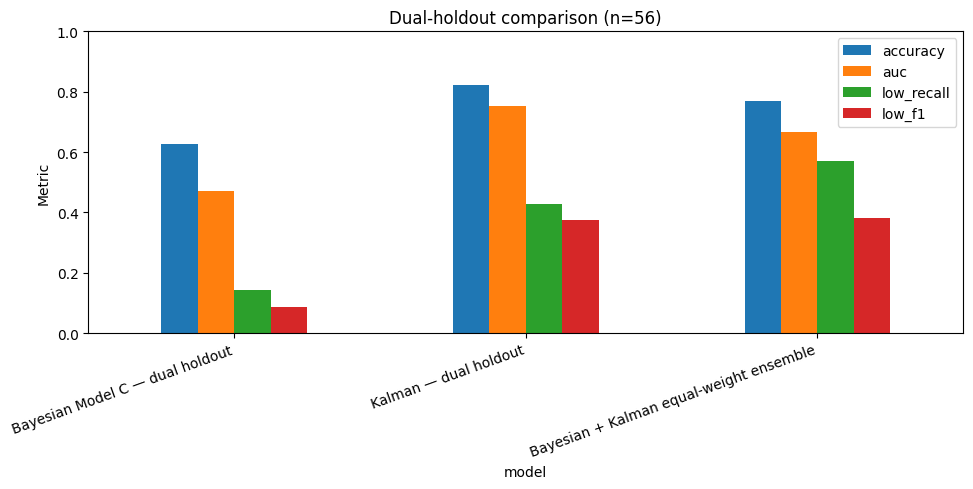

In [36]:
dual_metrics = pd.DataFrame()
dual_decisions = pd.DataFrame()

if len(kalman_test):
    kcols = [
        "original_row_index", "class3_paper", "low_paper",
        "paper_p_low", "paper_p_moderate", "paper_p_normal",
        "y_pred", "actual_y",
    ]
    dual = bayes_pred_df.merge(
        kalman_test[kcols], on="original_row_index", how="inner", suffixes=("_bayes", "_kalman")
    )
    if len(dual):
        bayes_probs = dual[["p_low", "p_moderate", "p_normal"]].to_numpy(float)
        kalman_probs = dual[["paper_p_low", "paper_p_moderate", "paper_p_normal"]].to_numpy(float)
        ensemble_probs = 0.5 * bayes_probs + 0.5 * kalman_probs
        ensemble_probs = ensemble_probs / ensemble_probs.sum(axis=1, keepdims=True)
        y3 = dual["actual_class3"].to_numpy(int)
        y2 = dual["actual_low"].to_numpy(int)

        dual_rows = [
            metrics_3class(y3, bayes_probs, "Bayesian Model C — dual holdout"),
            metrics_3class(y3, kalman_probs, "Kalman — dual holdout"),
            metrics_3class(y3, ensemble_probs, "Bayesian + Kalman equal-weight ensemble"),
            metrics_binary(y2, bayes_probs[:, 0], COST_THRESHOLD, "Bayesian Model C — dual holdout"),
            metrics_binary(y2, kalman_probs[:, 0], COST_THRESHOLD, "Kalman — dual holdout"),
            metrics_binary(y2, ensemble_probs[:, 0], COST_THRESHOLD, "Bayesian + Kalman equal-weight ensemble"),
        ]
        dual_metrics = pd.DataFrame(dual_rows)
        dual_metrics.to_csv(OUTPUT_DIR / "validation_dual_holdout_metrics.csv", index=False)

        dual_decisions = dual.copy()
        dual_decisions["ensemble_p_low"] = ensemble_probs[:, 0]
        dual_decisions["ensemble_p_moderate"] = ensemble_probs[:, 1]
        dual_decisions["ensemble_p_normal"] = ensemble_probs[:, 2]
        dual_decisions["ensemble_class3"] = np.argmax(ensemble_probs, axis=1)
        dual_decisions["ensemble_low_cost"] = (ensemble_probs[:, 0] >= COST_THRESHOLD).astype(int)
        dual_decisions.to_csv(OUTPUT_DIR / "validation_dual_holdout_decisions.csv", index=False)
        display(dual_metrics)

        compare = dual_metrics[dual_metrics["task"].eq("2-class")][["model", "accuracy", "auc", "low_recall", "low_f1"]]
        compare.plot(x="model", y=["accuracy", "auc", "low_recall", "low_f1"], kind="bar", figsize=(10, 5))
        plt.ylim(0, 1)
        plt.ylabel("Metric")
        plt.title(f"Dual-holdout comparison (n={len(dual)})")
        plt.xticks(rotation=20, ha="right")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "validation_dual_holdout_comparison.png", dpi=160, bbox_inches="tight")
        plt.show()
    else:
        print("The paper test and temporal test have no overlapping rows.")
else:
    print("Dual-holdout validation skipped because Kalman forecasts are unavailable.")

## 16. Optional external validation on UCI SECOM

This section validates the **methodological pattern**, not the garment-specific Model C parameters:

- chronological train/validation/test split using SECOM timestamps;
- train-only missing-value handling, scaling, and feature selection;
- sparse Bayesian logistic regression using a Laplace prior;
- no SMOTE;
- validation-selected cost-sensitive threshold;
- rolling Bernoulli extended Kalman correction for time-varying baseline risk.

The Salem et al. (2018) values are included only as literature context because that study used 10-fold cross-validation and a different preprocessing pipeline.

## 17. Objective coverage and scientific-scope audit

In [38]:
coverage_rows = [
    ["Paper 3-class comparison", "Covered", "Exact Model C paper holdout", "Published exact rows are unavailable, so protocol is reproduced rather than claimed identical"],
    ["Paper 2-class comparison", "Covered", "Exact Model C posterior predictive low probability", "No SMOTE; default and fixed cost-sensitive decisions reported"],
    ["Driver comparison", "Covered", "Posterior effects + monotone spline + interactions", "Associational, not causal"],
    ["69.5 BDT threshold", "Covered", "Posterior risk/productivity curves by WIP", "Threshold is model-based and uncertainty-aware"],
    ["Forecast MAE/RMSE and interval coverage", "Covered", "Kalman temporal test", "Requires corrected v7.1 artifact"],
    ["Probability of a low day", "Covered", "Model C and Kalman probability outputs", "Definitions are kept explicit"],
    ["Incentive/WIP/workers what-if", "Covered", "Exact Model C reconstruction", "Offline predictive contrasts, not causal treatment effects"],
    ["Budget allocation", "Covered", "Greedy posterior expected uplift", "Offline model-based utility only"],
    ["Team heterogeneity", "Covered", "Team-specific posterior intervention summaries", "Uncertainty grows for small teams"],
    ["Weekday and quarter diagnostics", "Covered descriptively", "Kalman out-of-sample innovation groups", "Quarter is not a Model C coefficient"],
    ["Style-change dips/change points", "Covered", "Kalman innovation flags vs style-change rows", "Association does not establish causation"],
    ["Incentive/WIP coefficient drift", "Partially covered", "Residual-level Kalman drift and post-hoc diagnostics", "Saved v7.1 DLM tracks a local residual level, not separate time-varying incentive/WIP slopes"],
    ["Missing-WIP latent-state comparison", "Partially covered", "Indicator model plus scenario sensitivity", "A separately fitted latent-WIP Bayesian model is not available"],
    ["SECOM external validation", "Covered", "Sparse Bayesian logistic + Bernoulli EKF", "Validates the method pattern, not garment-specific parameters"],
]
coverage_audit = pd.DataFrame(coverage_rows, columns=["objective", "status", "evidence", "caveat"])
coverage_audit.to_csv(OUTPUT_DIR / "validation_objective_coverage_audit.csv", index=False)
display(coverage_audit)

,objective,status,evidence,caveat
0,Paper 3-class comparison,Covered,Exact Model C paper holdout,"Published exact rows are unavailable, so proto..."
1,Paper 2-class comparison,Covered,Exact Model C posterior predictive low probabi...,No SMOTE; default and fixed cost-sensitive dec...
2,Driver comparison,Covered,Posterior effects + monotone spline + interact...,"Associational, not causal"
3,69.5 BDT threshold,Covered,Posterior risk/productivity curves by WIP,Threshold is model-based and uncertainty-aware
4,Forecast MAE/RMSE and interval coverage,Covered,Kalman temporal test,Requires corrected v7.1 artifact
5,Probability of a low day,Covered,Model C and Kalman probability outputs,Definitions are kept explicit
6,Incentive/WIP/workers what-if,Covered,Exact Model C reconstruction,"Offline predictive contrasts, not causal treat..."
7,Budget allocation,Covered,Greedy posterior expected uplift,Offline model-based utility only
8,Team heterogeneity,Covered,Team-specific posterior intervention summaries,Uncertainty grows for small teams
9,Weekday and quarter diagnostics,Covered descriptively,Kalman out-of-sample innovation groups,Quarter is not a Model C coefficient


## 18. Generate the final validation summary

In [39]:
three = classification_metrics[classification_metrics["task"].eq("3-class")].iloc[0]
two_default = classification_metrics[
    classification_metrics["model"].str.contains("default", case=False, na=False)
].iloc[0]
two_cost = classification_metrics[
    classification_metrics["model"].str.contains("cost-sensitive", case=False, na=False)
].iloc[0]

summary_lines = [
    "# Validation Summary — Exact Model C + Kalman DLM",
    "",
    "## Direct garment-paper validation",
    f"- Exact Model C 3-class accuracy: **{three['accuracy']:.3f}**; paper tree-ensemble reference: **{PAPER_3CLASS['accuracy']:.3f}**.",
    f"- Exact Model C 2-class default accuracy/AUC: **{two_default['accuracy']:.3f} / {two_default['auc']:.3f}**.",
    f"- Exact Model C 2-class cost-sensitive low recall/F1: **{two_cost['low_recall']:.3f} / {two_cost['low_f1']:.3f}**; paper GBT+SMOTE reference: **{PAPER_2CLASS['low_recall']:.3f} / {PAPER_2CLASS['low_f1']:.3f}**.",
    f"- Model C test MAE/RMSE: **{regression_summary['mae']:.3f} / {regression_summary['rmse']:.3f}**.",
    "",
    "## Decisions and added value",
    f"- Paper threshold checked at **{PAPER_INCENTIVE_THRESHOLD} BDT** with posterior risk curves stratified by WIP.",
    "- Row-level what-if, team heterogeneity, missing-WIP sensitivity, and budget-allocation outputs were generated.",
]

if len(kalman_metrics):
    km = kalman_metrics.iloc[0]
    summary_lines += [
        f"- Kalman future-test MAE/RMSE: **{km['mae']:.3f} / {km['rmse']:.3f}**.",
        f"- Kalman future-test paper-style low AUC/AP: **{km['paper_low_auc']:.3f} / {km['paper_low_ap']:.3f}**.",
    ]
if len(dual_metrics):
    dm = dual_metrics[(dual_metrics["task"].eq("2-class")) & dual_metrics["model"].str.contains("ensemble")].iloc[0]
    summary_lines += [
        f"- Bayesian+Kalman dual-holdout ensemble 2-class accuracy/AUC: **{dm['accuracy']:.3f} / {dm['auc']:.3f}** on **n={int(dm['n'])}** rows.",
    ]
if len(secom_metrics):
    sm = secom_metrics[secom_metrics["model"].str.contains("EKF")].iloc[0]
    summary_lines += [
        "",
        "## SECOM external validation",
        f"- Sparse Bayesian logistic + EKF test AUC/recall: **{sm['auc']:.3f} / {sm['recall_fail']:.3f}** under a chronological split without SMOTE.",
    ]

summary_lines += [
    "",
    "## Important limitations",
    "- Paper benchmark row membership was not published.",
    "- Predictive what-if differences are not causal effects.",
    "- The saved Kalman v7.1 model tracks residual-level drift rather than separate time-varying incentive and WIP coefficients.",
    "- Missing-WIP sensitivity is not a separately fitted latent-state WIP model.",
]

summary_text = "\n".join(summary_lines)
(OUTPUT_DIR / "validation_summary.md").write_text(summary_text, encoding="utf-8")
print(summary_text)

manifest = pd.DataFrame({
    "file": [str(p.relative_to(REPO_DIR)) for p in sorted(OUTPUT_DIR.glob("*"))],
    "size_kb": [p.stat().st_size / 1024 for p in sorted(OUTPUT_DIR.glob("*"))],
})
manifest.to_csv(OUTPUT_DIR / "validation_output_manifest.csv", index=False)
display(manifest)

# Validation Summary — Exact Model C + Kalman DLM

## Direct garment-paper validation
- Exact Model C 3-class accuracy: **0.747**; paper tree-ensemble reference: **0.839**.
- Exact Model C 2-class default accuracy/AUC: **0.825 / 0.675**.
- Exact Model C 2-class cost-sensitive low recall/F1: **0.375 / 0.324**; paper GBT+SMOTE reference: **0.880 / 0.910**.
- Model C test MAE/RMSE: **0.095 / 0.130**.

## Decisions and added value
- Paper threshold checked at **69.5 BDT** with posterior risk curves stratified by WIP.
- Row-level what-if, team heterogeneity, missing-WIP sensitivity, and budget-allocation outputs were generated.
- Kalman future-test MAE/RMSE: **0.086 / 0.132**.
- Kalman future-test paper-style low AUC/AP: **0.715 / 0.348**.
- Bayesian+Kalman dual-holdout ensemble 2-class accuracy/AUC: **0.768 / 0.668** on **n=56** rows.

## Important limitations
- Paper benchmark row membership was not published.
- Predictive what-if differences are not causal effects.
- The saved Kalman v7.

,file,size_kb
0,output/validation/validation_actionable_thresh...,0.386719
1,output/validation/validation_artifact_audit.csv,0.335938
2,output/validation/validation_bayesian_binary_b...,0.176758
3,output/validation/validation_bayesian_low_cali...,62.543945
4,output/validation/validation_bayesian_paper_pr...,37.838867
5,output/validation/validation_bayesian_regressi...,0.258789
6,output/validation/validation_bayesian_regressi...,99.546875
7,output/validation/validation_budget_allocation...,16.200195
8,output/validation/validation_budget_allocation...,0.313477
9,output/validation/validation_budget_utility.png,43.955078


## 19. Save this notebook into the repository (optional in Colab)

When opened from an uploaded `.ipynb`, Colab may not expose the notebook itself as `/content/validation.ipynb`. Set `COPY_NOTEBOOK_TO_REPO=True` only when that file exists in the Colab file pane. Generated validation outputs do not depend on this step.

In [ ]:
COPY_NOTEBOOK_TO_REPO = False
NOTEBOOK_CANDIDATE = Path("/content/validation.ipynb")
NOTEBOOK_REPO_PATH = CODES_DIR / "validation.ipynb"

if COPY_NOTEBOOK_TO_REPO:
    if not NOTEBOOK_CANDIDATE.exists():
        raise FileNotFoundError(
            "Upload validation.ipynb to /content first, then rerun this cell."
        )
    shutil.copy2(NOTEBOOK_CANDIDATE, NOTEBOOK_REPO_PATH)
    print("Copied notebook to:", NOTEBOOK_REPO_PATH)
else:
    print("Notebook copy skipped. Outputs are already stored under output/validation/.")

## 20. Commit and push validation outputs to GitHub

In [ ]:
PUSH_TO_GITHUB = True
COMMIT_MESSAGE = "Add exact Model C and Kalman validation outputs"

if PUSH_TO_GITHUB:
    run_cmd(["git", "-C", str(REPO_DIR), "config", "user.name", "Dakshi Validation"])
    run_cmd(["git", "-C", str(REPO_DIR), "config", "user.email", "validation@users.noreply.github.com"])

    paths_to_add = [str(OUTPUT_DIR.relative_to(REPO_DIR))]
    if NOTEBOOK_REPO_PATH.exists():
        paths_to_add.append(str(NOTEBOOK_REPO_PATH.relative_to(REPO_DIR)))
    run_cmd(["git", "-C", str(REPO_DIR), "add", *paths_to_add])

    status = run_cmd(["git", "-C", str(REPO_DIR), "status", "--porcelain"], check=False)
    if not status.stdout.strip():
        print("No new validation changes to commit.")
    else:
        run_cmd(["git", "-C", str(REPO_DIR), "commit", "-m", COMMIT_MESSAGE])

        branch_result = run_cmd(
            ["git", "-C", str(REPO_DIR), "rev-parse", "--abbrev-ref", "HEAD"],
            check=True,
        )
        branch = branch_result.stdout.strip() or "main"

        token = getpass("GitHub personal access token for push: ").strip()
        if not token:
            raise RuntimeError("Push requested but no GitHub token was supplied.")

        env = os.environ.copy()
        env["GITHUB_TOKEN"] = token
        env["GIT_TERMINAL_PROMPT"] = "0"
        askpass = BASE_DIR / ".git_askpass_validation_push.sh"
        askpass.write_text(
            "#!/bin/sh\n"
            "case \"$1\" in\n"
            "  *Username*) echo x-access-token ;;\n"
            "  *Password*) echo \"$GITHUB_TOKEN\" ;;\n"
            "esac\n"
        )
        askpass.chmod(askpass.stat().st_mode | stat.S_IXUSR)
        env["GIT_ASKPASS"] = str(askpass)

        try:
            run_cmd(["git", "-C", str(REPO_DIR), "pull", "--rebase", "origin", branch], env=env, check=False)
            run_cmd(["git", "-C", str(REPO_DIR), "push", "origin", branch], env=env)
            print("Validation outputs pushed to GitHub.")
        finally:
            token = ""
            env.pop("GITHUB_TOKEN", None)
            askpass.unlink(missing_ok=True)
else:
    print("Git push disabled. Set PUSH_TO_GITHUB=True to commit and push outputs.")

## References

- Al Imran, A. A., Rahim, M. S., & Ahmed, T. (2021). *Mining the productivity data of the garment industry*. International Journal of Business Intelligence and Data Mining, 19(3), 319–342. DOI: 10.1504/IJBIDM.2021.118183.
- UCI Machine Learning Repository. *Productivity Prediction of Garment Employees*. DOI: 10.24432/C51S6D.
- McCann, M., & Johnston, A. (2008). *SECOM*. UCI Machine Learning Repository. DOI: 10.24432/C54305.
- Salem, M., Taheri, S., & Yuan, J.-S. (2018). *An Experimental Evaluation of Fault Diagnosis from Imbalanced and Incomplete Data for Smart Semiconductor Manufacturing*. Big Data and Cognitive Computing, 2(4), 30.